In [1]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import statsmodels.formula.api as smf
import math

In [2]:
base_dir = "/Users/seohyon/resources/results"

# will track only these methods (above BBKNN)
keep_methods = [
    "embed_cell_types_jittered",
    "embed_cell_types",
    "shuffle_integration",
    "shuffle_integration_by_cell_type",
    "shuffle_integration",
    "scanvi",
    "combat",
    "scvi",
    "harmony",
    "harmonypy",
    "batchelor_fastmnn",
    "liger",
    "pyliger",
    "scalex",
    "uce",
    "no_integration",
    "no_integration_batch",
    "scanorama"
]

yaml_path = "/Users/seohyon/resources/results/run_2025-10-11_13-28-50/score_uns.yaml"
rows = []

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

for entry in data:
    method = entry.get("method_id", "").strip().lower()

    # keep only desired methods
    if method not in keep_methods:
        continue

    metrics = entry.get("metric_ids", [])
    values = entry.get("metric_values", [])

    for m_id, m_val in zip(metrics, values):
        rows.append({
            "dataset_id": entry.get("dataset_id"),
            "method_id": method,
            "metric_id": m_id,
            "metric_value": m_val
        })

In [3]:
df = pd.DataFrame(rows)
df = df.dropna(subset=["metric_value"]).copy() # drop NaN
# df = df[df["metric_id"] != "kbet"].copy() # drop kbet
df = df[~df["metric_id"].isin(["kbet", "hvg_overlap"])].copy() # drop unwanted metrics
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # clean the dataset id

In [4]:
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Copy of Tabellenblatt3.csv")

df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

control_type_map = {
    "embed_cell_types": "positive",
    "embed_cell_types_jittered": "positive",
    "shuffle_integration": "negative",
    "shuffle_integration_by_batch": "negative",
    "shuffle_integration_by_cell_type": "negative",
    "no_integration": "baseline",
    "no_integration_batch": "baseline",
}

df["control_type"] = df["method_id"].map(control_type_map).fillna("non-control")
df["control_group"] = df["control_type"].apply(
    lambda x: "non-control method" if x == "non-control" else "control method"
)

# mapping categorical to binary for plotting
df["nested_batches_num"] = df["nested_batches"].map({"No": 0, "Yes": 1})

bio_metrics = [
    'ari',
    'nmi',
    'clisi',
    'cell_cycle_conservation',
    'asw_label',
    'isolated_label_f1',
    'isolated_label_asw',
]

batch_metrics = [
    'pcr',
    'graph_connectivity',
    'ilisi',
    'asw_batch',
    'kbet_pg',
    'kbet_pg_label',
    'ari_batch',
    'nmi_batch',
]

def categorize_metric(m):
    if m in bio_metrics:
        return "bio"
    if m in batch_metrics:
        return "batch"
    return "baseline"

df["metric_type"] = df["metric_id"].apply(categorize_metric)

In [5]:
baseline = df[df["metric_type"] == "baseline"]
non_baseline = df[df["metric_type"] != "baseline"]

# For non-baseline, the metric_group is just metric_type ("bio" or "batch")
non_baseline = non_baseline.assign(metric_group=non_baseline["metric_type"])

# Duplicate baseline rows: one copy for "bio", one for "batch"
baseline_bio = baseline.copy()
baseline_bio["metric_group"] = "bio"

baseline_batch = baseline.copy()
baseline_batch["metric_group"] = "batch"

# Combine everything
df = pd.concat(
    [non_baseline, baseline_bio, baseline_batch],
    ignore_index=True
)

# Preparing for supplementary tables and figures

In [104]:
all_stats_bio = pd.DataFrame(columns=["Metric", "Method", "Slope", "p-value", "R^2"])
all_stats_batch = pd.DataFrame(columns=["Metric", "Method", "Slope", "p-value", "R^2"])

In [74]:
 df.query("metric_type == 'bio'")["metric_id"].unique()

array(['clisi', 'cell_cycle_conservation', 'asw_label', 'ari', 'nmi',
       'isolated_label_asw', 'isolated_label_f1'], dtype=object)

In [76]:
metrics = df.query("metric_type == 'bio'")["metric_id"].unique()

rows_all = []

for metric in metrics:
    df_metric = df.query("metric_id == @metric and control_group == 'non-control method'").copy()

    for method, df_m in df_metric.groupby("method_id"):
        # skip methods with too few points or no variation in x
        if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
            continue

        res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

        rows_all.append({
            "Metric": metric.replace("_","\\_"),
            "Method": method.replace("_","\\_"),
            "Slope": res.params["batch_imbalance_gc"],
            "p-value": res.pvalues["batch_imbalance_gc"],
            "R^2": res.rsquared,
        })
        
all_stats_bio = pd.concat([all_stats_bio, pd.DataFrame(rows_all)], ignore_index=True)

print(all_stats_bio.head())

  Metric              Method     Slope   p-value       R^2
0  clisi  batchelor\_fastmnn -0.000139  0.974589  0.000287
1  clisi              combat  0.001256  0.779339  0.021961
2  clisi             harmony  0.000890  0.889926  0.005404
3  clisi           harmonypy  0.000633  0.916080  0.003137
4  clisi               liger  0.009283  0.532612  0.104203


/var/folders/hn/2jsgf5g54l9glw98f7345cb00000gn/T/ipykernel_2013/2035817326.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_stats_bio = pd.concat([all_stats_bio, pd.DataFrame(rows_all)], ignore_index=True)


In [79]:
# TSV
all_stats_bio.to_csv("/Users/seohyon/Downloads/all_stats_bio.tsv", sep='\t', index=False, header=True)
    
# all_stats_bio.to_latex(
#     "/Users/seohyon/Downloads/all_stats_bio.tex",
#     index=False,
#     float_format="%.4g",
#     escape=True,
#     caption="Statistical values of per-method linear regression of metric value on batch imbalance.",
#     label="tab:all_stats_bio",
#     longtable=True
# )

In [105]:
metrics = df.query("metric_type == 'batch'")["metric_id"].unique()

rows_all = []

for metric in metrics:
    df_metric = df.query("metric_id == @metric and control_group == 'non-control method'").copy()

    for method, df_m in df_metric.groupby("method_id"):
        # skip methods with too few points or no variation in x
        if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
            continue

        res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

        rows_all.append({
            "Metric": metric.replace("_","\\_"),
            "Method": method.replace("_","\\_"),
            "Slope": res.params["batch_imbalance_gc"],
            "p-value": res.pvalues["batch_imbalance_gc"],
            "R^2": res.rsquared,
        })
        
all_stats_batch = pd.concat([all_stats_batch, pd.DataFrame(rows_all)], ignore_index=True)

print(all_stats_batch.head())

  Metric              Method     Slope   p-value       R^2
0  ilisi  batchelor\_fastmnn -0.329461  0.077464  0.582494
1  ilisi              combat -0.188301  0.123993  0.485468
2  ilisi             harmony -0.416373  0.053918  0.646239
3  ilisi           harmonypy -0.412096  0.057405  0.635867
4  ilisi               liger -0.531419  0.039463  0.694040


/var/folders/hn/2jsgf5g54l9glw98f7345cb00000gn/T/ipykernel_2013/3569744368.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_stats_batch = pd.concat([all_stats_batch, pd.DataFrame(rows_all)], ignore_index=True)


In [106]:
# CSV
all_stats_batch.to_csv("/Users/seohyon/Downloads/all_stats_batch.tsv", sep='\t', index=False, header=True)

# with kbet_pg

In [9]:
rows = []

for method, df_m in df.query("metric_id == 'kbet_pg' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)
# hits = results.query("r2 > 0.6 and pval < 0.05 and n >= 5")
# print(hits.sort_values("r2", ascending=False))

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6  1.249227  0.041163  0.687942
1              combat  6  1.320872  0.047333  0.666952
2             harmony  6  1.153508  0.056671  0.638018
3           harmonypy  6  1.156070  0.056349  0.638969
4               liger  6  0.768102  0.172963  0.406877
5             pyliger  6  0.749771  0.195191  0.376401
6              scalex  6  1.270630  0.053848  0.646450
7           scanorama  6  0.673696  0.508722  0.116078
8              scanvi  6  1.191429  0.053949  0.646145
9                scvi  6  1.223104  0.049013  0.661515
10                uce  6  1.283465  0.040087  0.691784


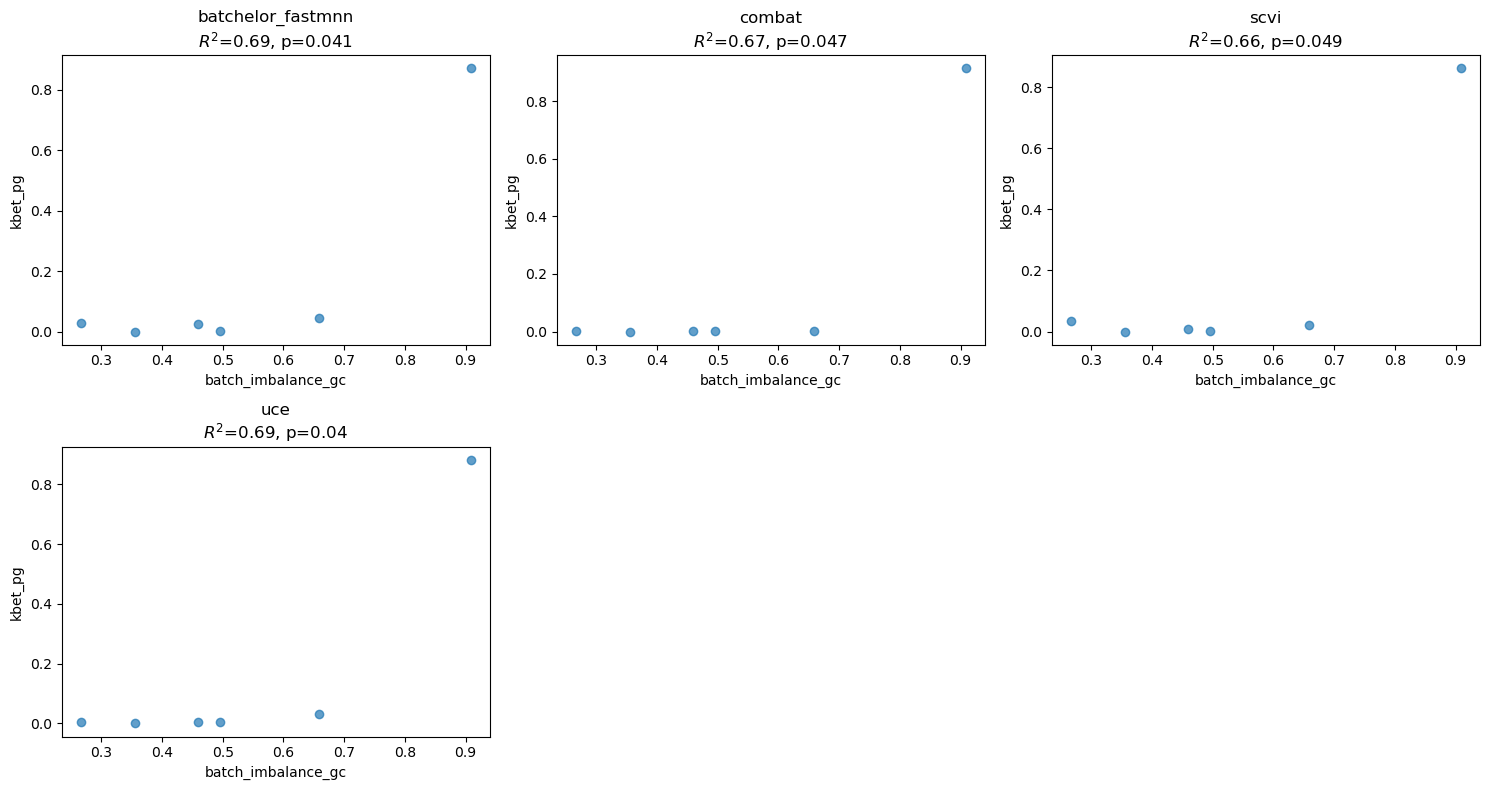

In [90]:
df_metric = df.query("metric_id == 'kbet_pg'") 

methods = [
    "batchelor_fastmnn",
    "combat",
    "scvi",
    "uce",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    # x_pred = np.linspace(x.min(), x.max(), 100)
    # X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    # y_pred = res.predict(X_pred)
    # ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("kbet_pg")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

#fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.savefig("/Users/seohyon/Downloads/kbet_pg_batch_imb.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
rows = []

for method, df_m in df.query("metric_id == 'kbet_pg' and control_group == 'control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

                          method_id  n     slope      pval        r2
0                  embed_cell_types  6  0.440834  0.507207  0.116858
1         embed_cell_types_jittered  6  0.448217  0.491133  0.125342
2                    no_integration  6  1.267547  0.044893  0.675054
3              no_integration_batch  6  1.333026  0.047207  0.667367
4               shuffle_integration  6 -0.190426  0.013843  0.814199
5  shuffle_integration_by_cell_type  6  0.459711  0.468721  0.137819


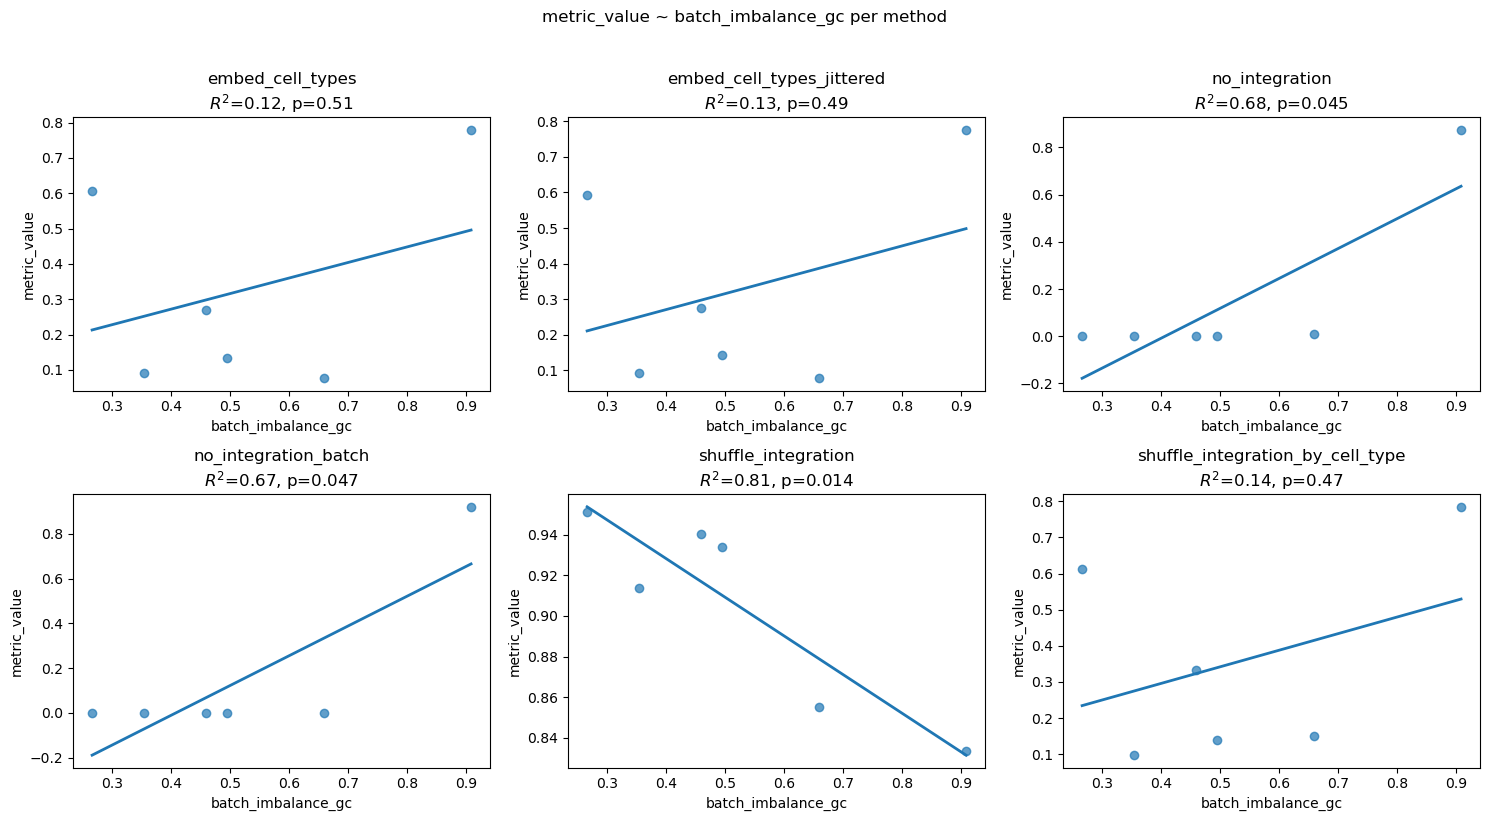

In [39]:
df_metric = df.query("metric_id == 'kbet_pg'") 

methods = [
    "embed_cell_types",
    "embed_cell_types_jittered",
    "no_integration",
    "no_integration_batch",
    "shuffle_integration",
    "shuffle_integration_by_cell_type",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()


# with kbet_pg_label

In [49]:
rows = []

for method, df_m in df.query("metric_id == 'kbet_pg_label' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6  0.901617  0.003278  0.907981
1              combat  6  1.324280  0.004166  0.896485
2             harmony  6  0.852319  0.018246  0.787806
3           harmonypy  6  0.836027  0.018402  0.786938
4               liger  6  0.414770  0.292955  0.267891
5             pyliger  6  0.380098  0.371343  0.201913
6              scalex  6  1.165815  0.013342  0.817477
7           scanorama  6  0.793986  0.262864  0.297620
8              scanvi  6  1.036573  0.005288  0.883640
9                scvi  6  1.103663  0.004498  0.892507
10                uce  6  1.227614  0.000918  0.950933


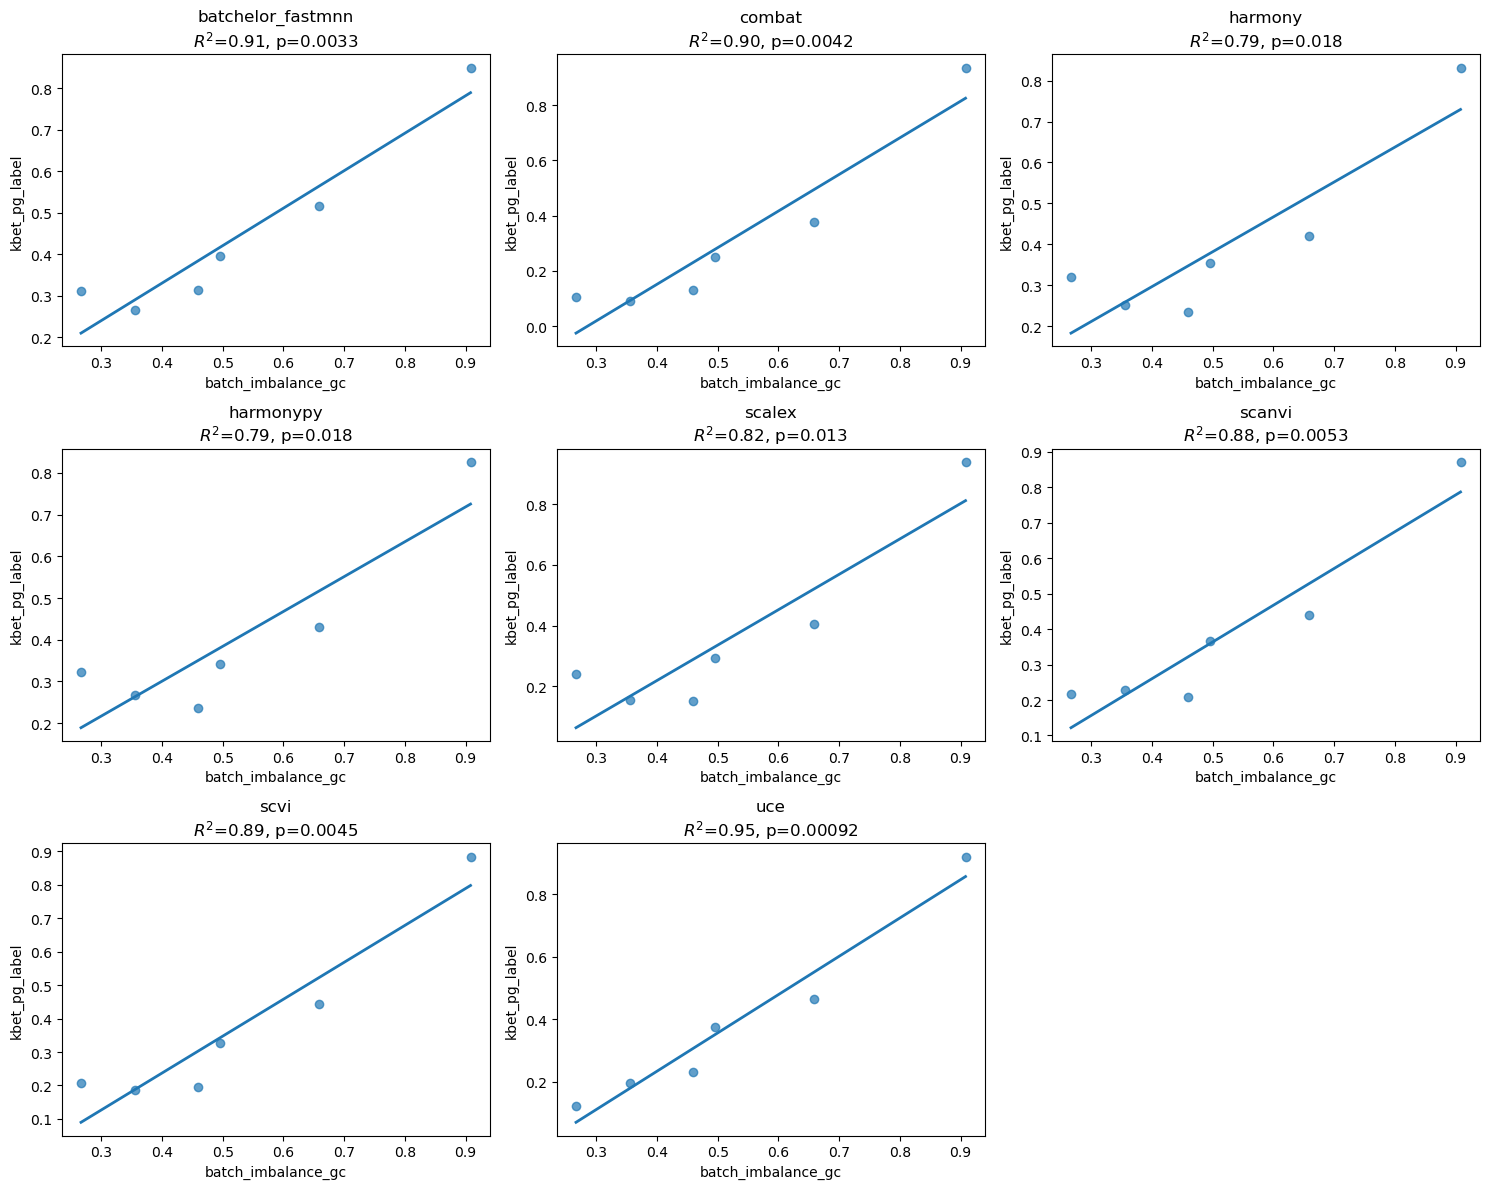

In [99]:
df_metric = df.query("metric_id == 'kbet_pg_label'") 

methods = [
    "batchelor_fastmnn",
    "combat",
    "harmony",
    "harmonypy",
    "scalex",
    "scanvi",
    "scvi",
    "uce",
]
# methods = [
#     "liger",
#     "pyliger",
# ]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")


    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)
    
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("kbet_pg_label")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

#fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.savefig("/Users/seohyon/Downloads/kbet_pg_label.png", dpi=300, bbox_inches="tight")
plt.show()

In [56]:
rows = []

for method, df_m in df.query("metric_id == 'kbet_pg_label' and control_group == 'control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

                          method_id  n     slope      pval        r2
0                  embed_cell_types  6 -0.110760  0.297314  0.263809
1         embed_cell_types_jittered  6 -0.113507  0.279702  0.280641
2                    no_integration  6  1.267438  0.002256  0.923443
3              no_integration_batch  6  1.464271  0.003023  0.911584
4               shuffle_integration  6 -0.096224  0.338874  0.227440
5  shuffle_integration_by_cell_type  6 -0.084194  0.412766  0.172540


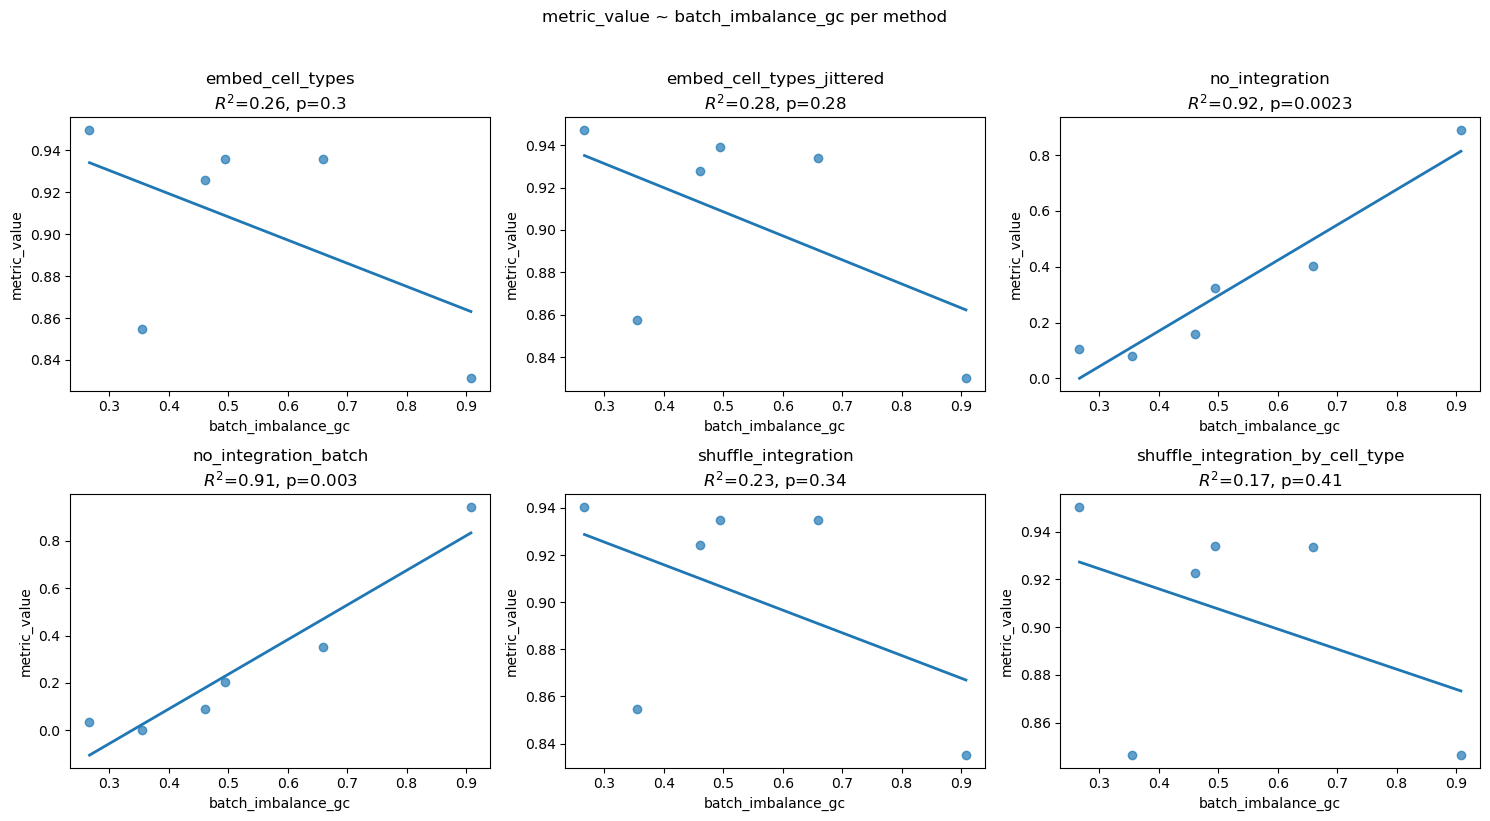

In [57]:
df_metric = df.query("metric_id == 'kbet_pg_label'") 

methods = [
    "embed_cell_types",
    "embed_cell_types_jittered",
    "no_integration",
    "no_integration_batch",
    "shuffle_integration",
    "shuffle_integration_by_cell_type",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()


# with ilisi

In [13]:
rows = []

for method, df_m in df.query("metric_id == 'ilisi' and control_group == 'non-control method'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

            method_id  n     slope      pval        r2
0   batchelor_fastmnn  6 -0.329461  0.077464  0.582494
1              combat  6 -0.188301  0.123993  0.485468
2             harmony  6 -0.416373  0.053918  0.646239
3           harmonypy  6 -0.412096  0.057405  0.635867
4               liger  6 -0.531419  0.039463  0.694040
5             pyliger  6 -0.531330  0.043555  0.679602
6              scalex  6 -0.358416  0.092542  0.547754
7           scanorama  6 -0.405965  0.009609  0.844301
8              scanvi  6 -0.382625  0.094183  0.544192
9                scvi  6 -0.356319  0.119893  0.492953
10                uce  6 -0.269811  0.083071  0.569122


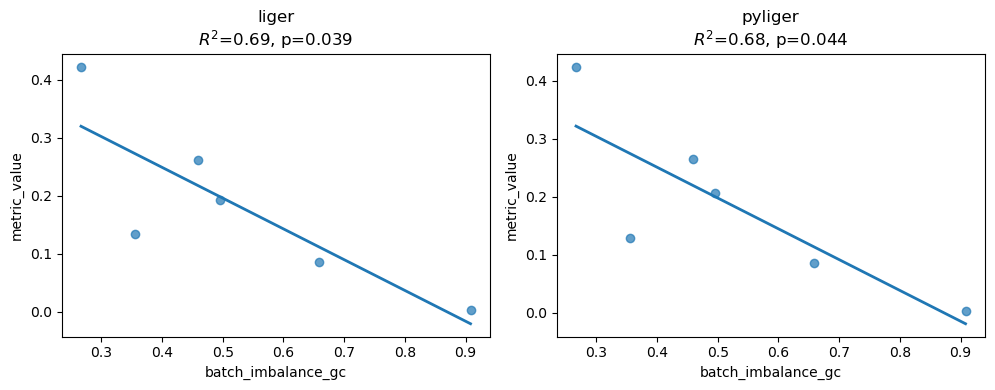

In [14]:
df_metric = df.query("metric_id == 'ilisi'") 

methods = [
    "liger",
    "pyliger",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

#fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.savefig("/Users/seohyon/Downloads/ilisi_batch_imb.png", dpi=300, bbox_inches="tight")
plt.show()

# with clisi

In [65]:
rows = []

for method, df_m in df.query("metric_id == 'clisi'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

                           method_id  n         slope      pval        r2
0                  batchelor_fastmnn  6 -1.385289e-04  0.974589  0.000287
1                             combat  6  1.255711e-03  0.779339  0.021961
2                   embed_cell_types  6 -3.330669e-16  0.495057      -inf
3          embed_cell_types_jittered  6  3.330669e-16  0.742379      -inf
4                            harmony  6  8.897702e-04  0.889926  0.005404
5                          harmonypy  6  6.334501e-04  0.916080  0.003137
6                              liger  6  9.282995e-03  0.532612  0.104203
7                     no_integration  6  8.197713e-04  0.842452  0.011114
8               no_integration_batch  6  7.137773e-03  0.134143  0.467622
9                            pyliger  6  5.200497e-03  0.736535  0.031509
10                            scalex  6  1.702368e-02  0.308653  0.253439
11                         scanorama  6  1.839358e-01  0.359169  0.211210
12                            scanvi  

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


- error coming from -inf R^2
- none of the fittings passed the threshold

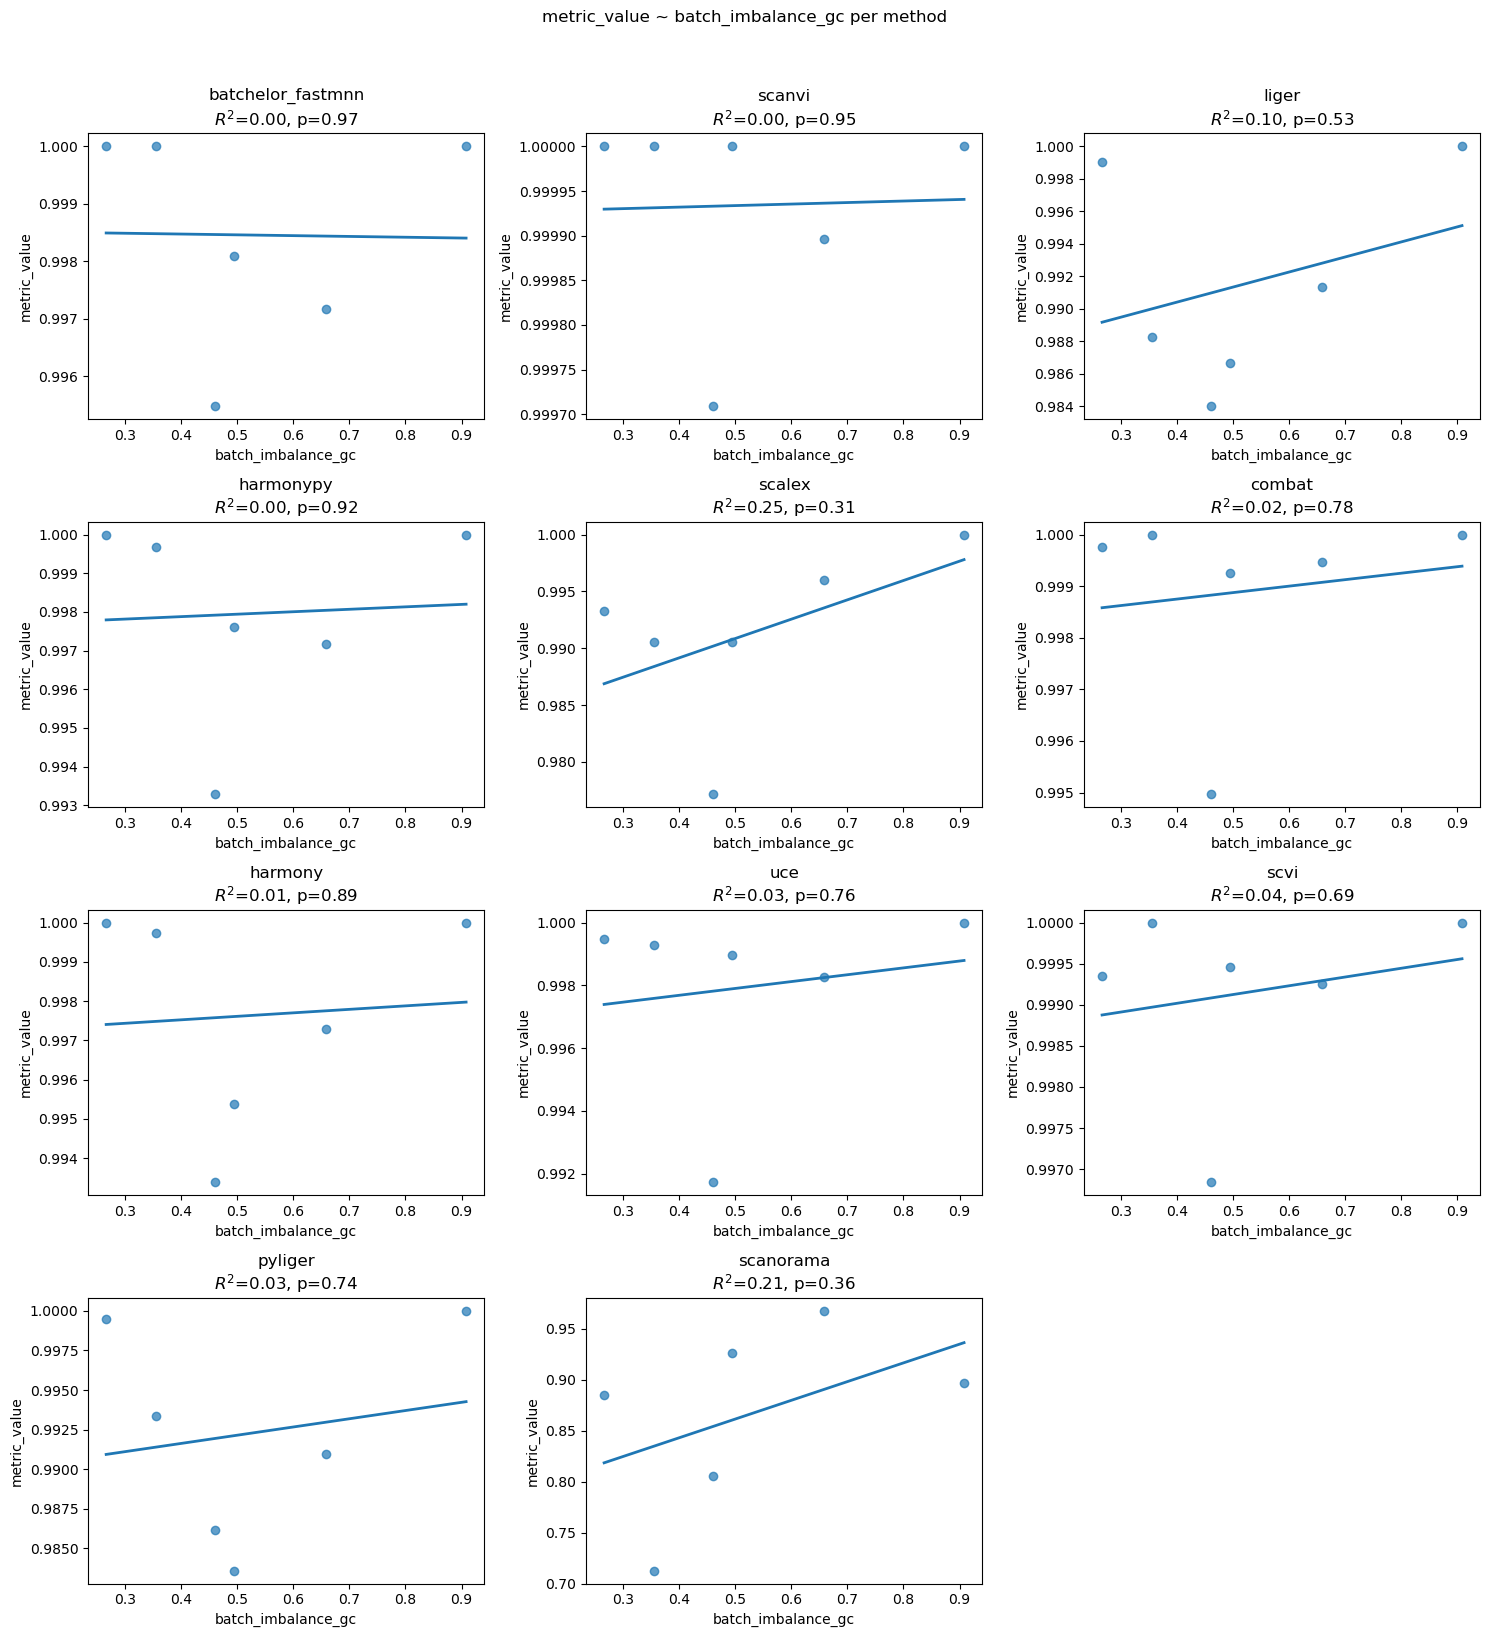

In [70]:
df_metric = df.query("metric_id == 'clisi'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

- Although no good model fit, I can see they all scored very well clisi

# with cell_cycle_conservation

In [15]:
rows = []

for method, df_m in df.query("metric_id == 'cell_cycle_conservation'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)
print(results)

                           method_id  n     slope      pval        r2
0                  batchelor_fastmnn  6 -0.166689  0.323866  0.240064
1                             combat  6 -0.065866  0.433736  0.158900
2                   embed_cell_types  6 -0.378160  0.172700  0.407255
3          embed_cell_types_jittered  6 -0.377376  0.172586  0.407419
4                            harmony  6 -0.317735  0.005992  0.876302
5                          harmonypy  6 -0.313907  0.006661  0.869746
6                              liger  6  0.087093  0.387140  0.190312
7                     no_integration  6 -0.344300  0.010650  0.836333
8               no_integration_batch  6 -0.116617  0.301540  0.259903
9                            pyliger  6  0.156907  0.543223  0.099181
10                            scalex  6 -0.013782  0.962043  0.000641
11                         scanorama  6 -0.176700  0.554242  0.094125
12                            scanvi  6  0.051635  0.790614  0.019745
13                  

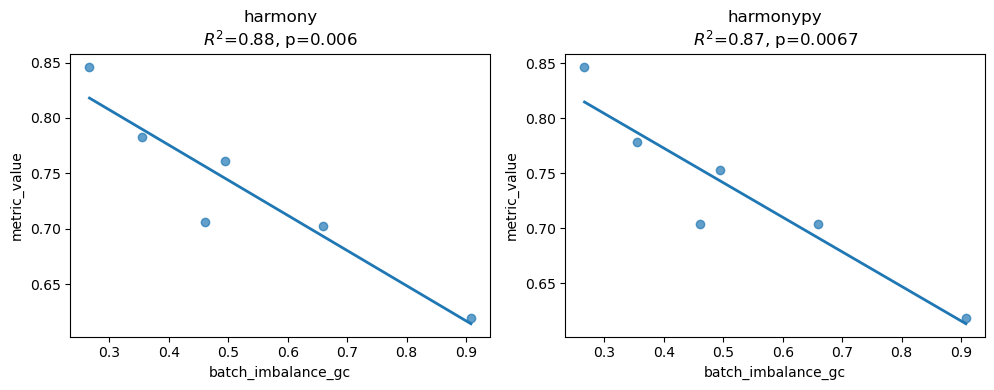

In [16]:
df_metric = df.query("metric_id == 'cell_cycle_conservation'") 

methods = [
    "harmony",
    "harmonypy",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

#fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.savefig("/Users/seohyon/Downloads/cell_cycle_batch_imb.png", dpi=300, bbox_inches="tight")

plt.show()

- negative

# with asw_label

In [73]:
rows = []

for method, df_m in df.query("metric_id == 'asw_label'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

                           method_id  n     slope      pval        r2
0                  batchelor_fastmnn  6 -0.102758  0.487901  0.127094
1                             combat  6  0.001863  0.987677  0.000067
2                   embed_cell_types  6 -0.010566  0.652633  0.055676
3          embed_cell_types_jittered  6 -0.010543  0.653344  0.055439
4                            harmony  6 -0.023022  0.895702  0.004850
5                          harmonypy  6 -0.027958  0.871188  0.007411
6                              liger  6 -0.028042  0.898021  0.004636
7                     no_integration  6 -0.043510  0.725817  0.034186
8               no_integration_batch  6  0.092495  0.466433  0.139137
9                            pyliger  6 -0.017329  0.937873  0.001717
10                            scalex  6  0.055740  0.716779  0.036535
11                         scanorama  6 -0.074430  0.537971  0.101647
12                            scanvi  6 -0.015922  0.851431  0.009875
13                  

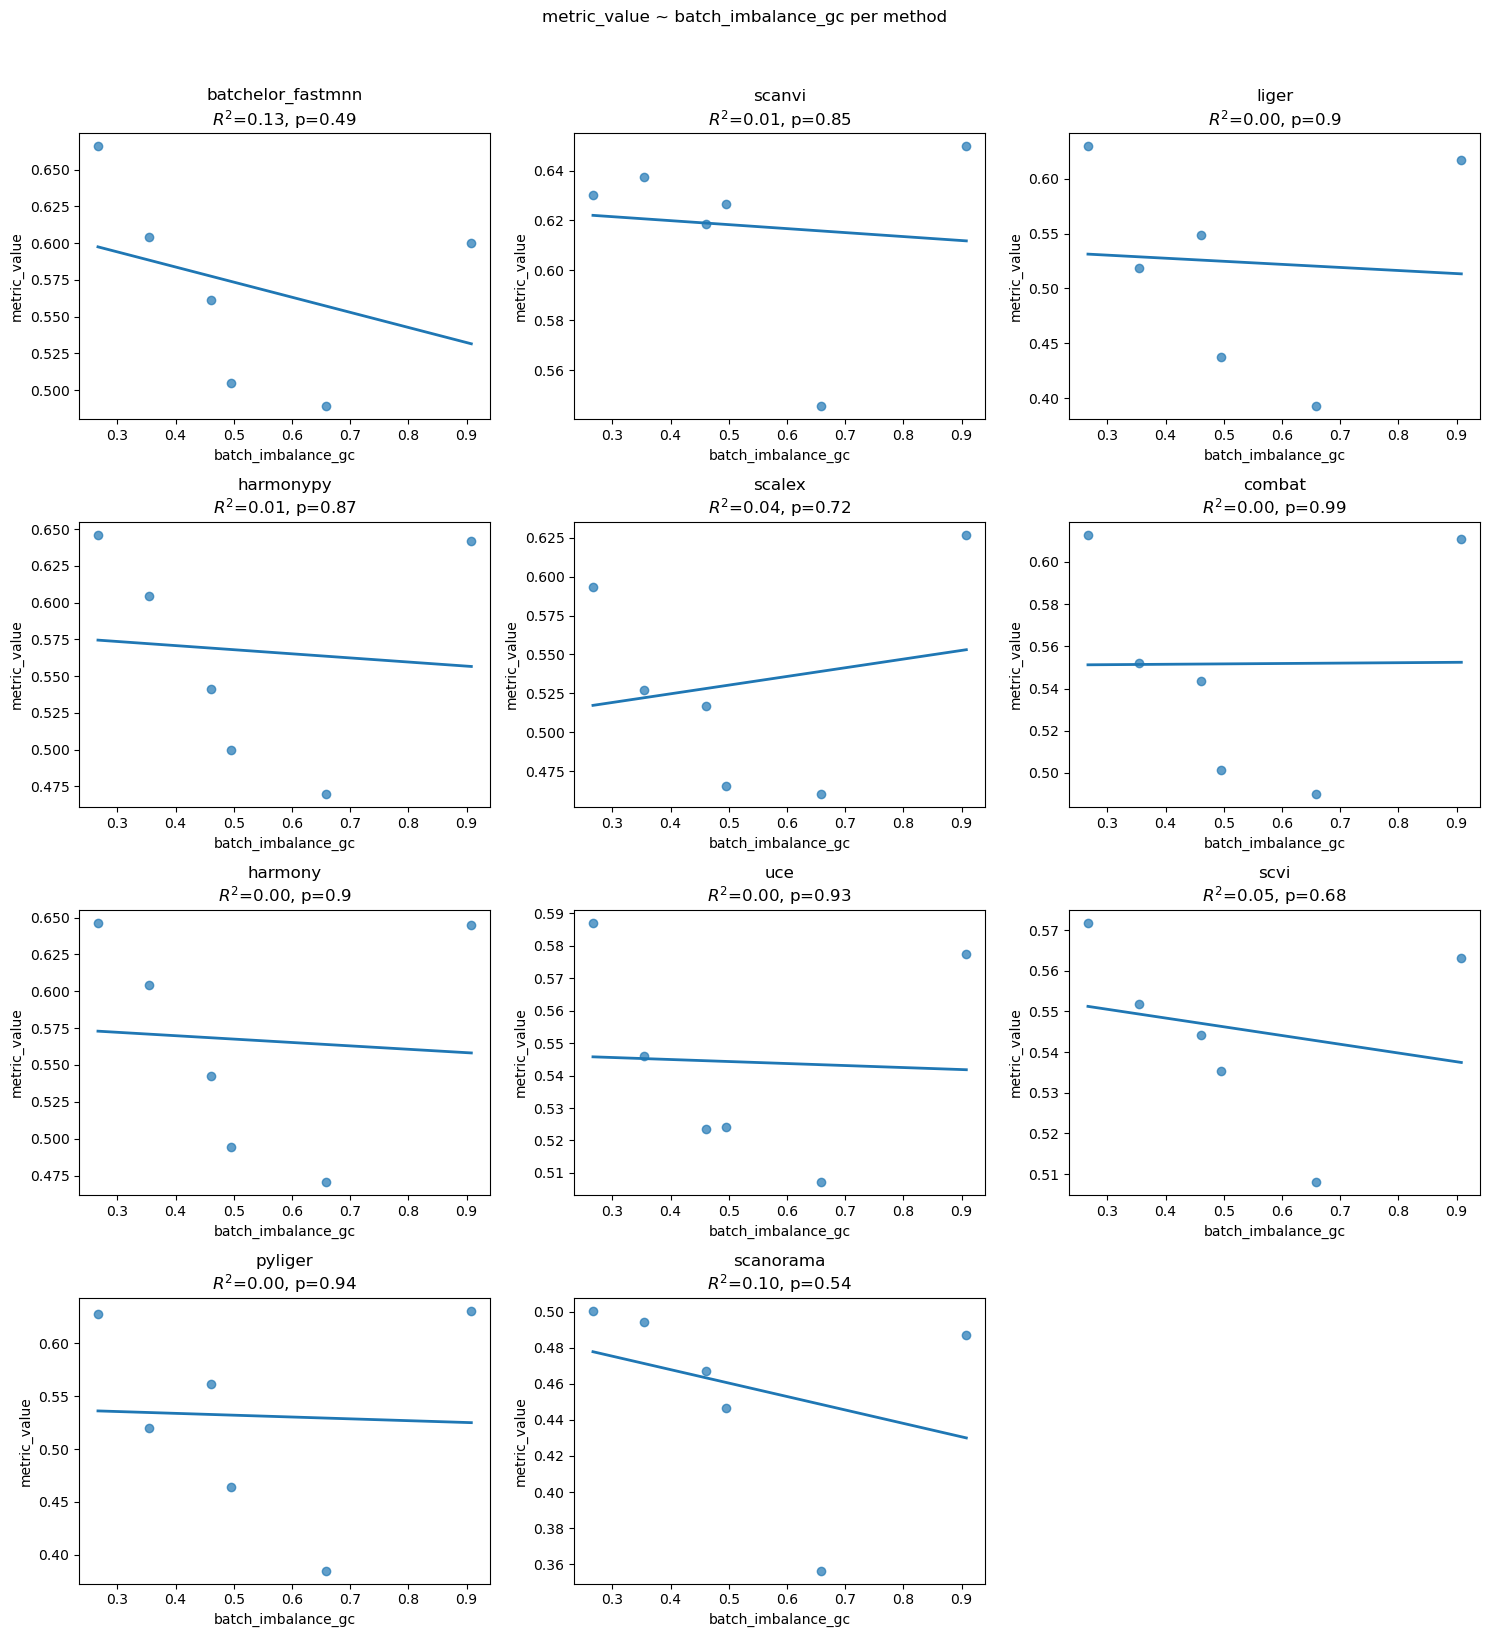

In [75]:
df_metric = df.query("metric_id == 'asw_label'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

- unlike clisi, where it gave good scores to all of them, it's not the case here: no trend

# with asw_batch

In [76]:
rows = []

for method, df_m in df.query("metric_id == 'asw_batch'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

                           method_id  n     slope      pval        r2
0                  batchelor_fastmnn  6 -0.078255  0.114504  0.503055
1                             combat  6 -0.109972  0.222191  0.342712
2                   embed_cell_types  6 -0.068961  0.623861  0.065729
3          embed_cell_types_jittered  6 -0.064736  0.659083  0.053550
4                            harmony  6 -0.129848  0.166261  0.416625
5                          harmonypy  6 -0.134296  0.148456  0.443952
6                              liger  6 -0.122837  0.489967  0.125972
7                     no_integration  6 -0.089551  0.161916  0.423095
8               no_integration_batch  6 -0.164024  0.367228  0.205020
9                            pyliger  6 -0.210680  0.212097  0.354917
10                            scalex  6 -0.074436  0.227553  0.336403
11                         scanorama  6 -0.101984  0.438760  0.155747
12                            scanvi  6 -0.138425  0.057805  0.634701
13                  

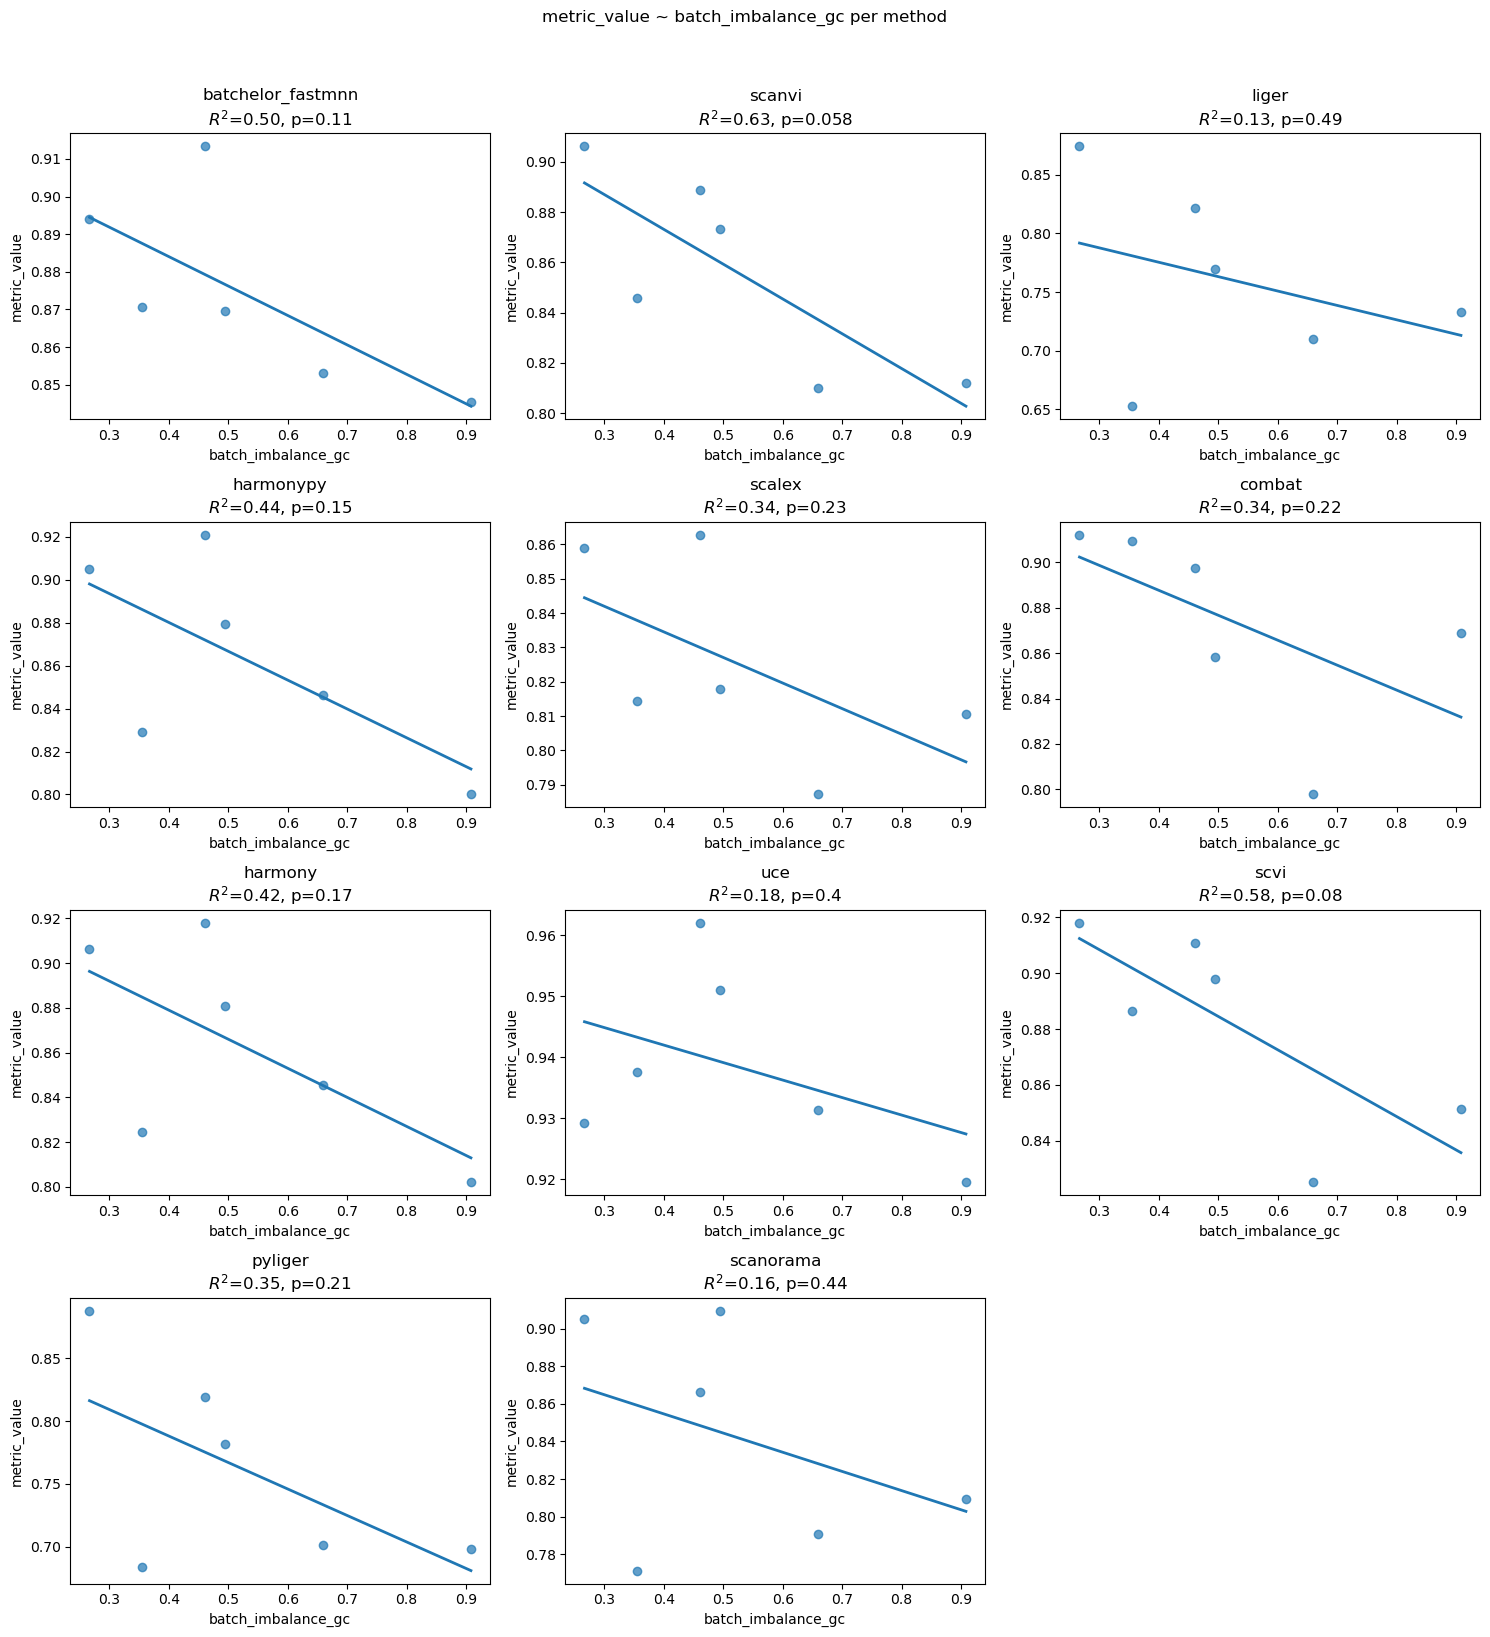

In [77]:
df_metric = df.query("metric_id == 'asw_batch'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

- no trend

# with ari

In [17]:
rows = []

for method, df_m in df.query("metric_id == 'ari'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

                           method_id  n     slope      pval        r2
0                  batchelor_fastmnn  6 -0.491675  0.024902  0.753821
1                             combat  6 -0.725950  0.014334  0.811053
2                   embed_cell_types  6 -0.000002  0.581794  0.082172
3          embed_cell_types_jittered  6 -0.000004  0.581794  0.082172
4                            harmony  6 -0.737240  0.006475  0.871533
5                          harmonypy  6 -0.413241  0.163399  0.420873
6                              liger  6 -0.771644  0.000699  0.957142
7                     no_integration  6 -0.365101  0.304822  0.256903
8               no_integration_batch  6  0.080061  0.613338  0.069644
9                            pyliger  6 -0.596294  0.002986  0.912114
10                            scalex  6 -0.123202  0.525329  0.107738
11                         scanorama  6 -0.176751  0.348447  0.219668
12                            scanvi  6 -1.016076  0.014646  0.809083
13                  

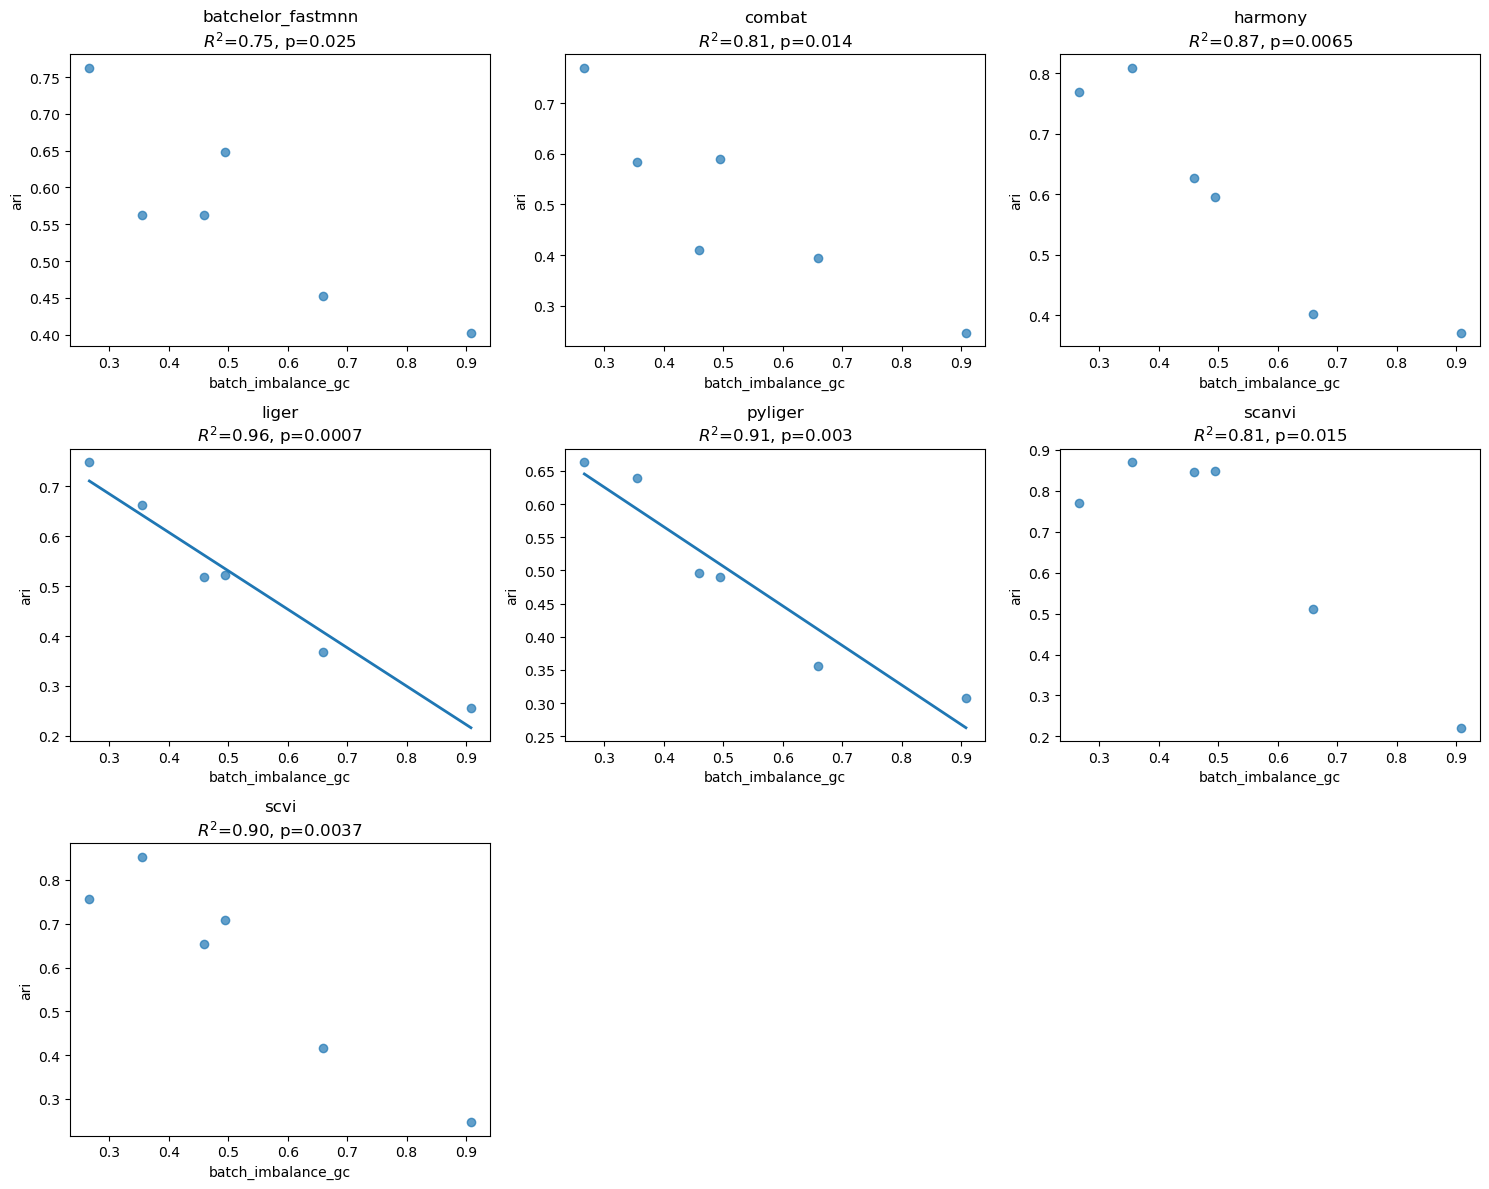

In [93]:
df_metric = df.query("metric_id == 'ari'") 

methods = [
    "batchelor_fastmnn",
    "combat",
    "harmony",
    "liger",
    "pyliger",
    "scanvi",
    "scvi",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")



    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    if method in ["liger", "pyliger"]:
        x_pred = np.linspace(x.min(), x.max(), 100)
        X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
        y_pred = res.predict(X_pred)
        ax.plot(x_pred, y_pred, linewidth=2)
    # if method == "pyliger":
    #     x_pred = np.linspace(x.min(), x.max(), 100)
    #     X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    #     y_pred = res.predict(X_pred)
    #     ax.plot(
    #         x_pred,
    #         y_pred,
    #         linewidth=2,
    #         color="0.6",        # grey (0=black, 1=white)
    #         linestyle="--"      # dashed
    #     )

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("ari")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

#fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.savefig("/Users/seohyon/Downloads/ari_batch_imb.png", dpi=300, bbox_inches="tight")

plt.show()

# with ari_batch

In [19]:
rows = []

for method, df_m in df.query("metric_id == 'ari_batch'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

                           method_id  n     slope      pval        r2
0                  batchelor_fastmnn  6  0.120799  0.181523  0.394817
1                             combat  6  0.043619  0.657618  0.054029
2                   embed_cell_types  6  0.099331  0.238832  0.323512
3          embed_cell_types_jittered  6  0.099330  0.238835  0.323508
4                            harmony  6  0.073139  0.142240  0.454031
5                          harmonypy  6  0.088578  0.140716  0.456548
6                              liger  6  0.041009  0.285649  0.274855
7                     no_integration  6  0.227998  0.096228  0.539808
8               no_integration_batch  6  0.366705  0.006401  0.872253
9                            pyliger  6  0.042104  0.188656  0.385083
10                            scalex  6 -0.003862  0.919379  0.002894
11                         scanorama  6  0.015735  0.838221  0.011724
12                            scanvi  6  0.075159  0.361269  0.209584
13                  

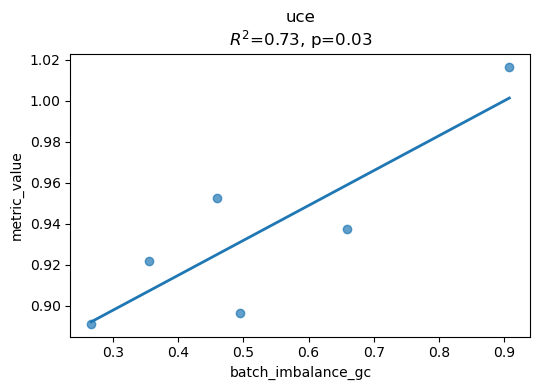

In [20]:
df_metric = df.query("metric_id == 'ari_batch'") 

methods = [
    "uce",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.savefig("/Users/seohyon/Downloads/ari_batch_batch_imb.png", dpi=300, bbox_inches="tight")

plt.show()

# with nmi

In [21]:
rows = []

for method, df_m in df.query("metric_id == 'nmi'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

                           method_id  n     slope      pval            r2
0                  batchelor_fastmnn  6 -0.209162  0.005060  8.861272e-01
1                             combat  6 -0.290941  0.024454  7.559383e-01
2                   embed_cell_types  6 -0.000005  0.581794  8.217164e-02
3          embed_cell_types_jittered  6 -0.000009  0.581794  8.217164e-02
4                            harmony  6 -0.237907  0.005578  8.805621e-01
5                          harmonypy  6 -0.180999  0.032471  7.208362e-01
6                              liger  6 -0.156676  0.266942  2.934243e-01
7                     no_integration  6 -0.182161  0.301773  2.596894e-01
8               no_integration_batch  6  0.268238  0.253756  3.071932e-01
9                            pyliger  6 -0.111801  0.293134  2.677226e-01
10                            scalex  6  0.105774  0.343428  2.237155e-01
11                         scanorama  6 -0.043396  0.856569  9.199587e-03
12                            scanvi  

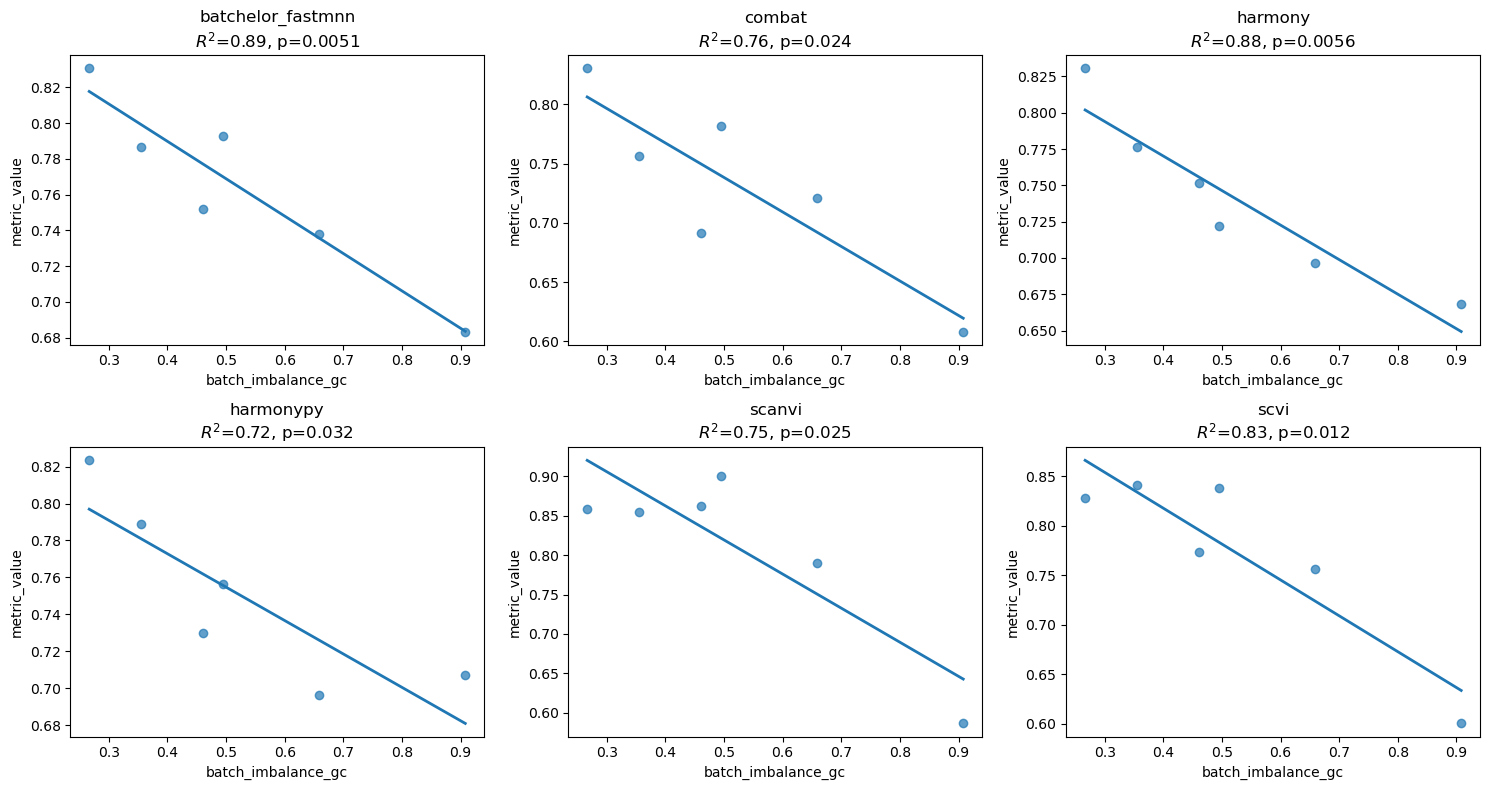

In [22]:
df_metric = df.query("metric_id == 'nmi'") 

methods = [
    "batchelor_fastmnn",
    "combat",
    "harmony",
    "harmonypy",
    "scanvi",
    "scvi",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

#fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.savefig("/Users/seohyon/Downloads/nmi_batch_imb.png", dpi=300, bbox_inches="tight")

plt.show()

# with nmi_batch

In [85]:
rows = []

for method, df_m in df.query("metric_id == 'nmi_batch'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

                           method_id  n     slope      pval            r2
0                  batchelor_fastmnn  6  0.117212  0.668297  5.059272e-02
1                             combat  6 -0.066686  0.853541  9.594694e-03
2                   embed_cell_types  6  0.068676  0.827614  1.332566e-02
3          embed_cell_types_jittered  6  0.068680  0.827602  1.332744e-02
4                            harmony  6  0.062995  0.718102  3.618601e-02
5                          harmonypy  6  0.069547  0.708614  3.872937e-02
6                              liger  6  0.079113  0.484135  1.291553e-01
7                     no_integration  6  0.272943  0.438046  1.561931e-01
8               no_integration_batch  6  0.632447  0.077847  5.815612e-01
9                            pyliger  6  0.093309  0.428625  1.621529e-01
10                            scalex  6 -0.018405  0.927987  2.308402e-03
11                         scanorama  6 -0.192178  0.476129  1.336098e-01
12                            scanvi  

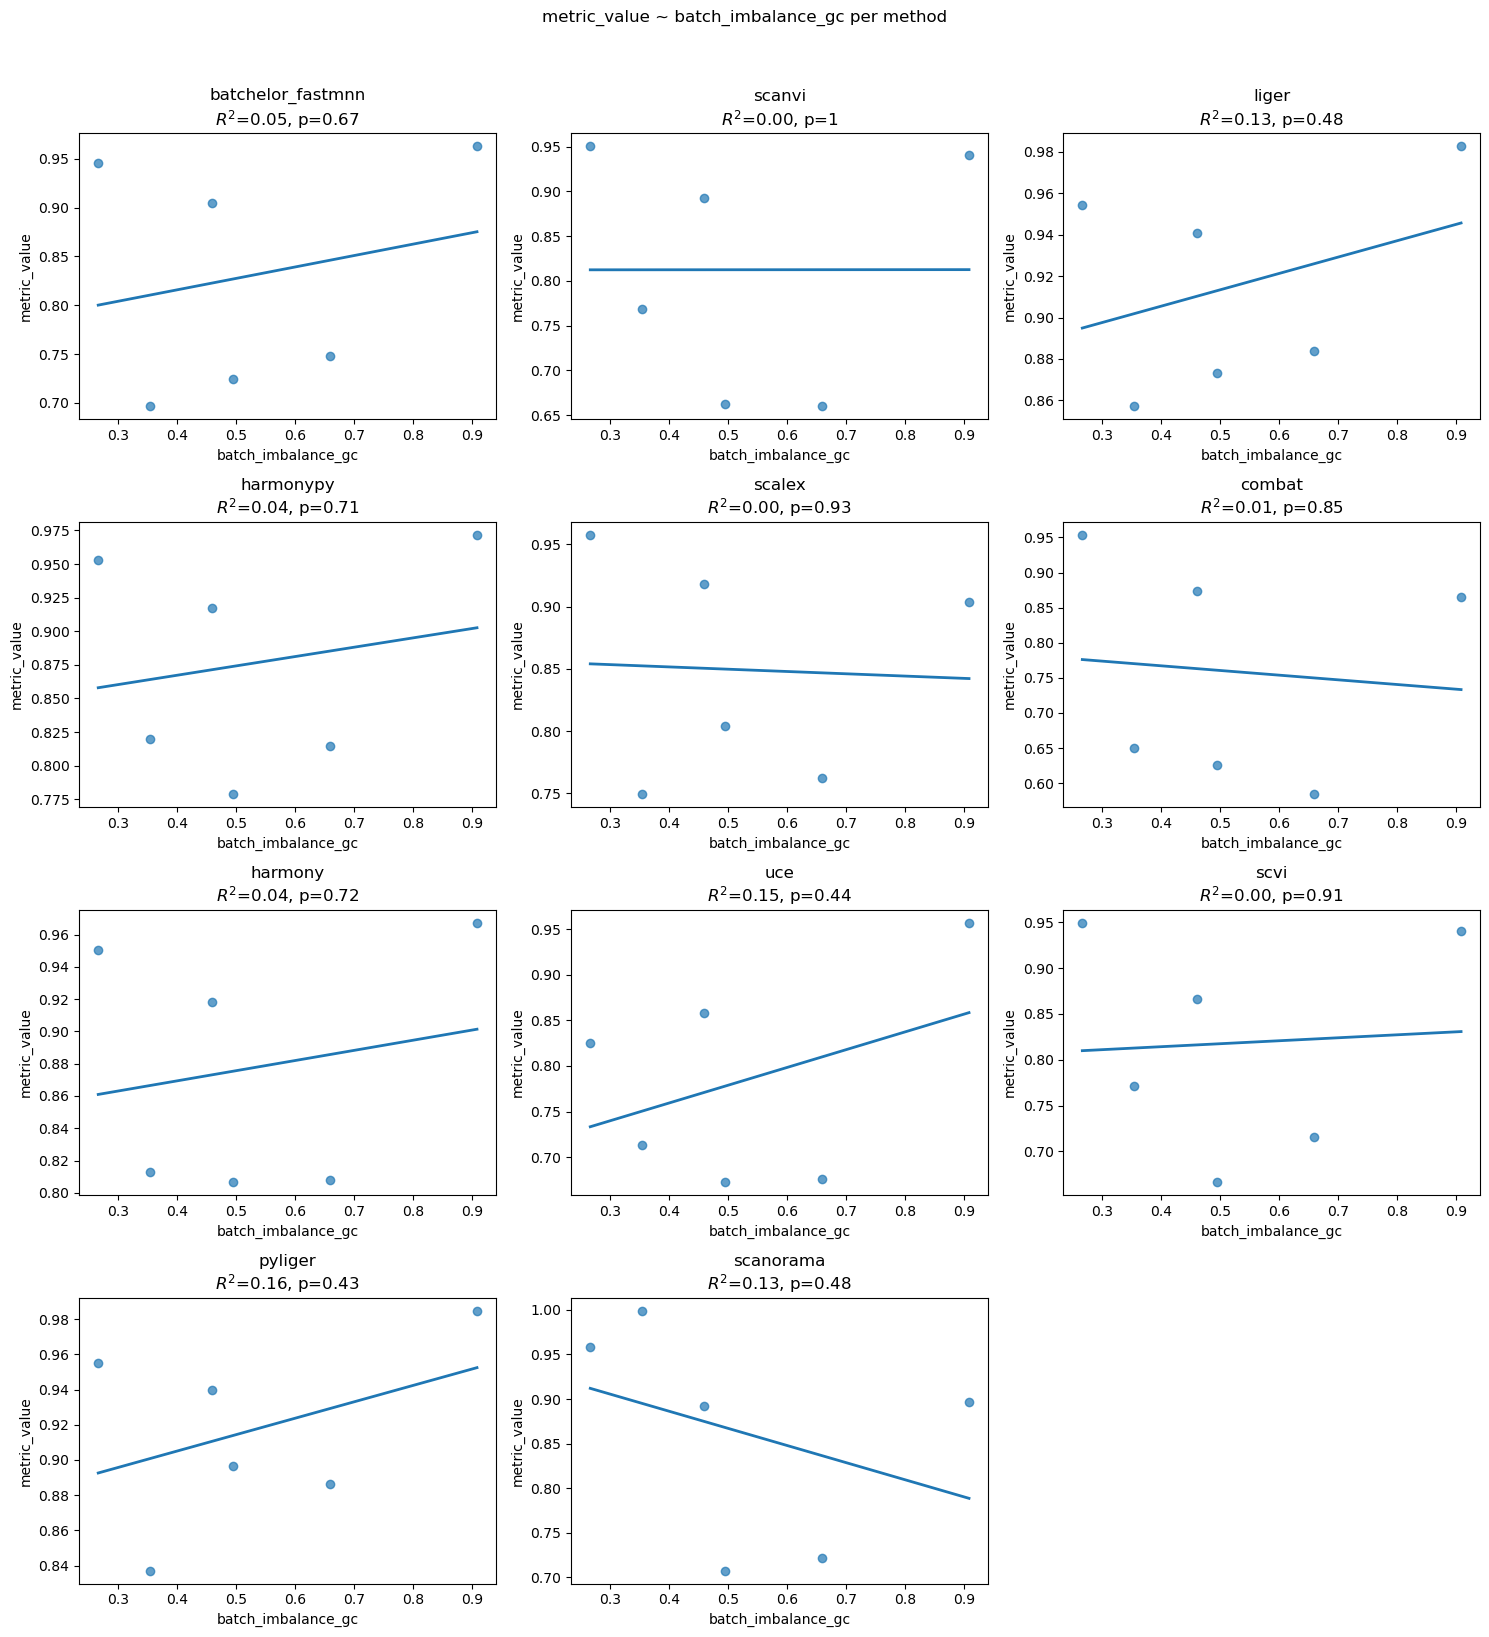

In [86]:
df_metric = df.query("metric_id == 'nmi_batch'") 

methods = df.query("control_group == 'non-control method'")["method_id"].unique()

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

- no trend

# with graph_connectivity

In [87]:
rows = []

for method, df_m in df.query("metric_id == 'graph_connectivity'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

                           method_id  n     slope      pval        r2
0                  batchelor_fastmnn  6 -0.178150  0.176160  0.402323
1                             combat  6 -0.124936  0.077356  0.582757
2                   embed_cell_types  6 -0.001587  0.581794  0.082172
3          embed_cell_types_jittered  6 -0.000635  0.581794  0.082172
4                            harmony  6 -0.114074  0.295940  0.265090
5                          harmonypy  6 -0.115522  0.316479  0.246484
6                              liger  6 -0.202157  0.593779  0.077269
7                     no_integration  6 -0.129968  0.073773  0.591624
8               no_integration_batch  6  0.468532  0.023761  0.759254
9                            pyliger  6 -0.211394  0.597806  0.075662
10                            scalex  6 -0.236163  0.213824  0.352798
11                         scanorama  6 -0.193496  0.563735  0.089897
12                            scanvi  6 -0.143067  0.010374  0.838404
13                  

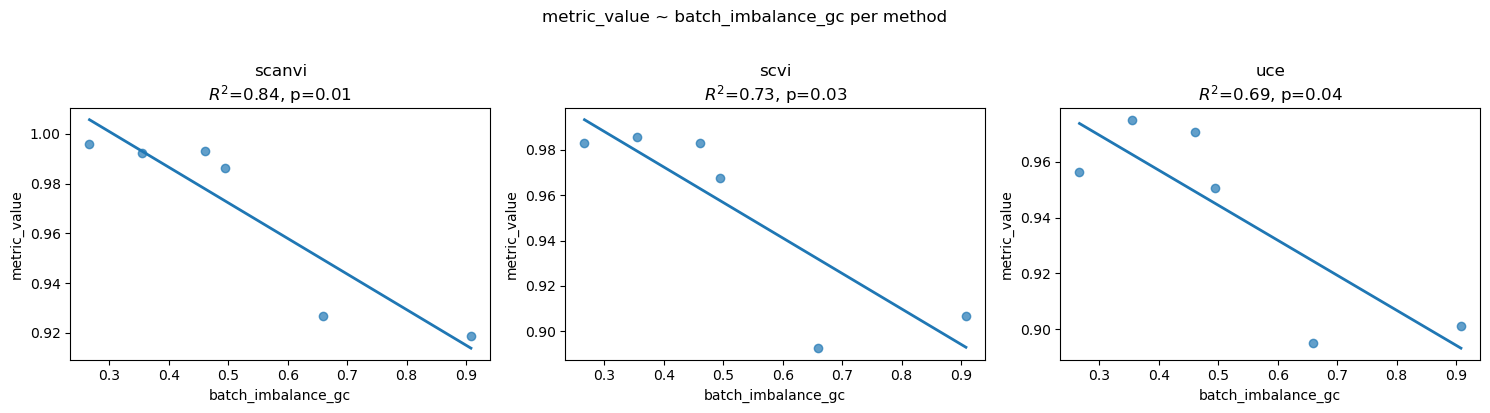

In [90]:
df_metric = df.query("metric_id == 'graph_connectivity'") 

methods = [
    "scanvi",
    "scvi",
    "uce",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.show()

# with isolated_label_asw

In [23]:
rows = []

for method, df_m in df.query("metric_id == 'isolated_label_asw'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

                           method_id  n     slope      pval        r2
0                  batchelor_fastmnn  5 -0.803929  0.023691  0.858261
1                             combat  5 -0.607452  0.009613  0.921235
2                   embed_cell_types  5 -0.002497  0.936868  0.002461
3          embed_cell_types_jittered  5 -0.002967  0.924770  0.003495
4                            harmony  5 -0.682740  0.006160  0.941209
5                          harmonypy  5 -0.670461  0.004927  0.949258
6                              liger  5 -0.433112  0.209513  0.458104
7                     no_integration  5 -0.726578  0.014971  0.894777
8               no_integration_batch  5 -0.196095  0.569756  0.118940
9                            pyliger  5 -0.469619  0.108298  0.631265
10                            scalex  5 -0.705076  0.016092  0.889709
11                         scanorama  5 -0.103340  0.175069  0.510509
12                            scanvi  5 -0.701391  0.019751  0.874007
13                  

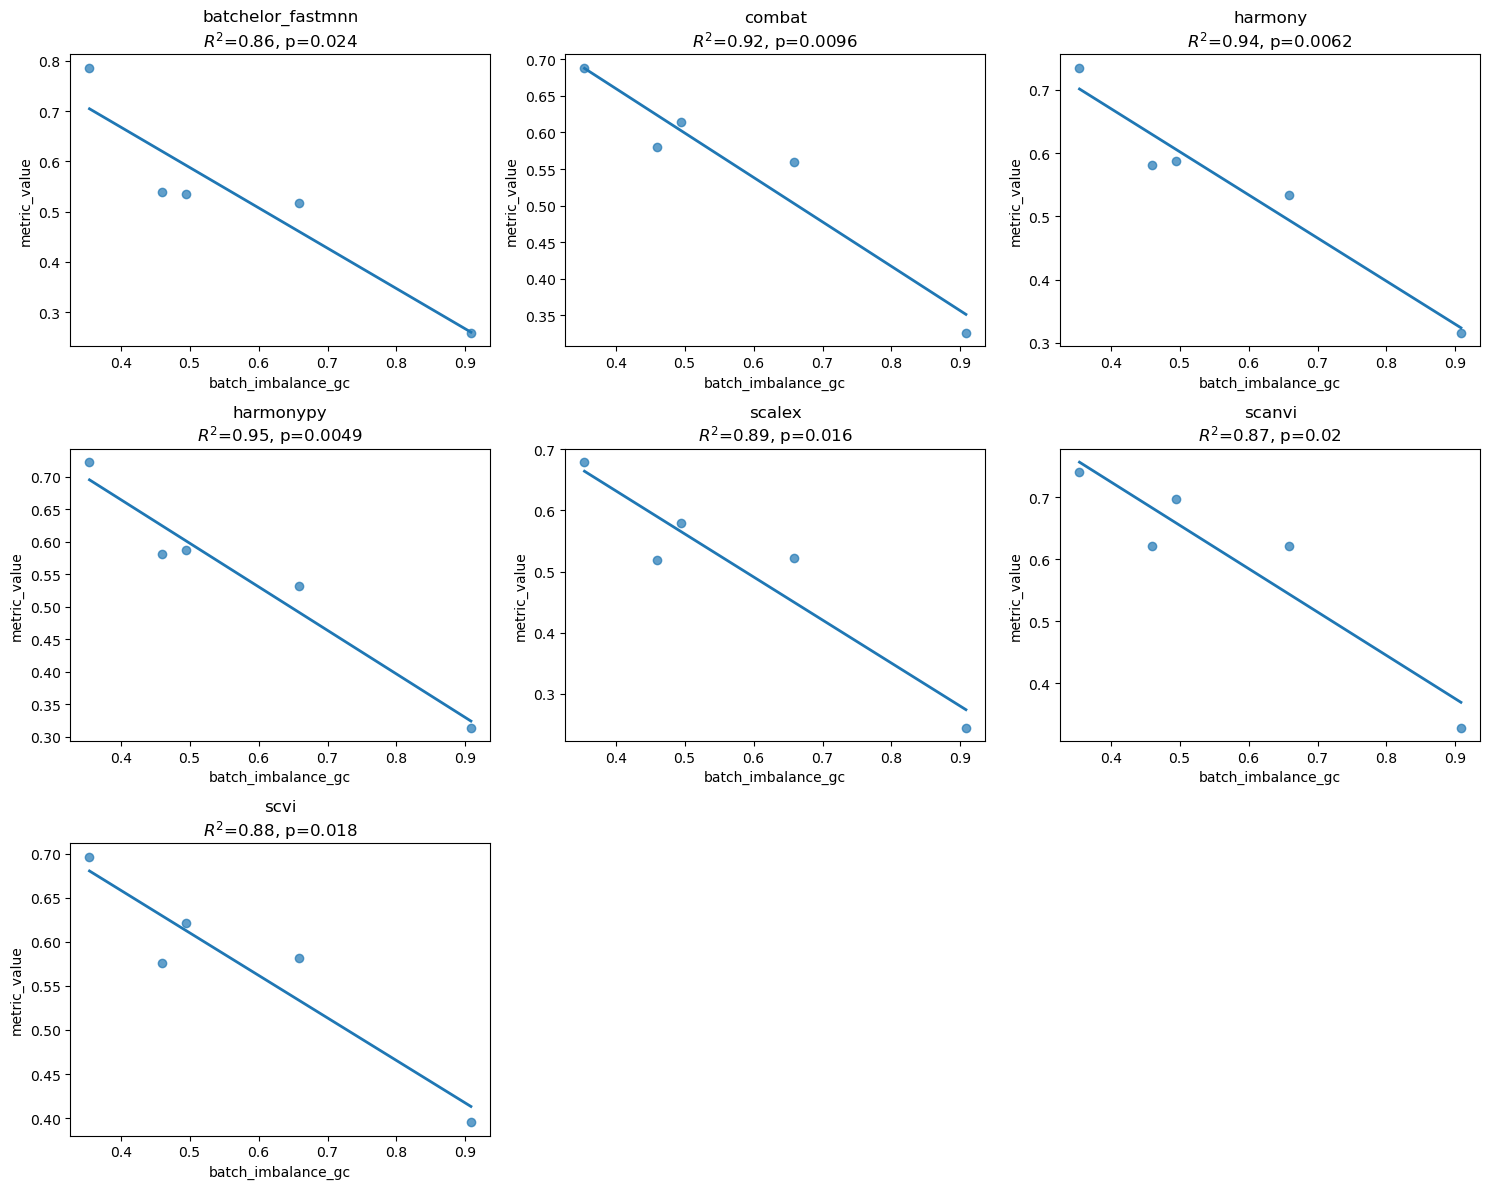

In [24]:
df_metric = df.query("metric_id == 'isolated_label_asw'") 

methods = [
    "batchelor_fastmnn",
    "combat",
    "harmony",
    "harmonypy",
    "scalex",
    "scanvi",
    "scvi",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

#fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.savefig("/Users/seohyon/Downloads/isolated_asw_batch_imb.png", dpi=300, bbox_inches="tight")

plt.show()

# with isolated_label_f1

In [25]:
rows = []

for method, df_m in df.query("metric_id == 'isolated_label_f1'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

                           method_id  n     slope      pval        r2
0                  batchelor_fastmnn  5 -1.007099  0.309624  0.331609
1                             combat  5 -0.852970  0.274245  0.372553
2                   embed_cell_types  5 -0.001771  0.726986  0.046708
3          embed_cell_types_jittered  5 -0.019437  0.726986  0.046708
4                            harmony  5 -0.061703  0.390097  0.250822
5                          harmonypy  5 -0.094182  0.311074  0.330007
6                              liger  5 -0.201680  0.048149  0.776864
7                     no_integration  5 -1.002521  0.280102  0.365516
8               no_integration_batch  5 -0.231311  0.274517  0.372224
9                            pyliger  5 -0.171475  0.084413  0.683207
10                            scalex  5 -0.061614  0.309298  0.331970
11                         scanorama  5  0.010094  0.821263  0.019838
12                            scanvi  5 -1.168132  0.264073  0.385030
13                  

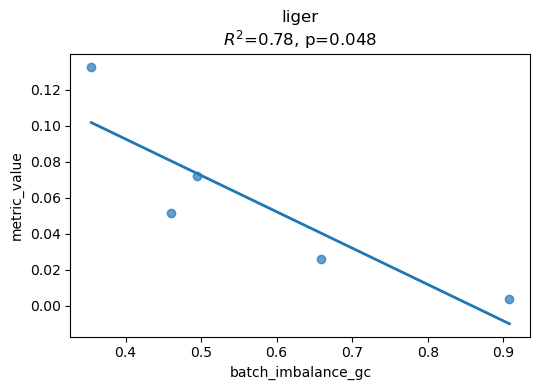

In [26]:
df_metric = df.query("metric_id == 'isolated_label_f1'") 

methods = [
    "liger",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("metric_value")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

#fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.savefig("/Users/seohyon/Downloads/isolated_f1_batch_imb.png", dpi=300, bbox_inches="tight")

plt.show()

# with pcr

In [27]:
rows = []

for method, df_m in df.query("metric_id == 'pcr'").groupby("method_id"):
    # skip methods with too few points or no variation
    if df_m["batch_imbalance_gc"].nunique() < 2 or len(df_m) < 4:
        continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    rows.append({
        "method_id": method,
        "n": len(df_m),
        "slope": res.params["batch_imbalance_gc"],
        "pval": res.pvalues["batch_imbalance_gc"],
        "r2": res.rsquared,
    })

results = pd.DataFrame(rows)

print(results)

                           method_id  n         slope      pval        r2
0                  batchelor_fastmnn  6 -2.429133e-01  0.548857  0.096575
1                             combat  6 -4.327643e-04  0.227609  0.336338
2                   embed_cell_types  6  1.049392e-01  0.871904  0.007328
3          embed_cell_types_jittered  6  1.044197e-01  0.872512  0.007259
4                            harmony  6 -9.537421e-02  0.617930  0.067920
5                          harmonypy  6 -7.872718e-02  0.721001  0.035428
6                              liger  6 -2.175567e-01  0.500073  0.120577
7                     no_integration  6 -1.260136e-07  0.880806  0.006341
8               no_integration_batch  6 -7.109736e-07  0.069631  0.602210
9                            pyliger  6 -1.263506e-01  0.605102  0.072799
10                            scalex  6  7.954136e-03  0.665662  0.051429
11                         scanorama  6 -1.162958e+00  0.118914  0.494767
12                            scanvi  

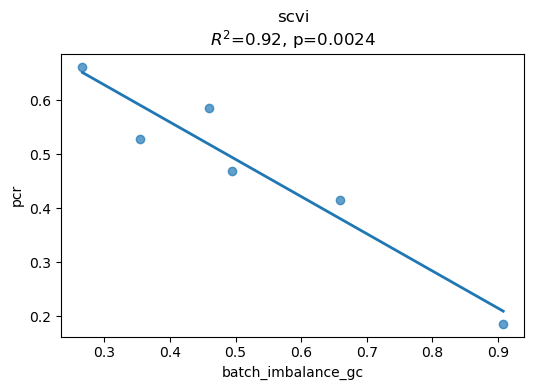

In [98]:
df_metric = df.query("metric_id == 'pcr'") 

methods = [
    "scvi",
]

n_methods = len(methods)
ncols = 3                      # change this if you want 2 per row, etc.
nrows = math.ceil(n_methods / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         squeeze=False)
axes = axes.ravel()

for ax, method in zip(axes, methods):
    df_m = df_metric.query("method_id == @method")

    # skip methods with too few points or no variation in x
    # if len(df_m) < 2 or df_m["batch_imbalance_gc"].nunique() < 2:
    #     ax.text(0.5, 0.5, "Not enough data",
    #             ha="center", va="center", transform=ax.transAxes)
    #     ax.set_title(method)
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    #     continue

    res = smf.ols("metric_value ~ batch_imbalance_gc", data=df_m).fit()

    # Scatter points
    x = df_m["batch_imbalance_gc"]
    y = df_m["metric_value"]
    ax.scatter(x, y, alpha=0.7)

    # Regression line
    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = pd.DataFrame({"batch_imbalance_gc": x_pred})
    y_pred = res.predict(X_pred)
    ax.plot(x_pred, y_pred, linewidth=2)

    # Labels & title with stats
    ax.set_xlabel("batch_imbalance_gc")
    ax.set_ylabel("pcr")
    ax.set_title(
        f"{method}\n$R^2$={res.rsquared:.2f}, "
        f"p={res.pvalues['batch_imbalance_gc']:.2g}"
    )

# ------------------------------------------------------------------
# 5) Hide unused axes if grid is larger than number of methods
# ------------------------------------------------------------------
for j in range(n_methods, len(axes)):
    fig.delaxes(axes[j])

#fig.suptitle("metric_value ~ batch_imbalance_gc per method", y=1.02)
fig.tight_layout()
plt.savefig("/Users/seohyon/Downloads/pcr_batch_imb.png", dpi=300, bbox_inches="tight")
plt.show()

# For defense

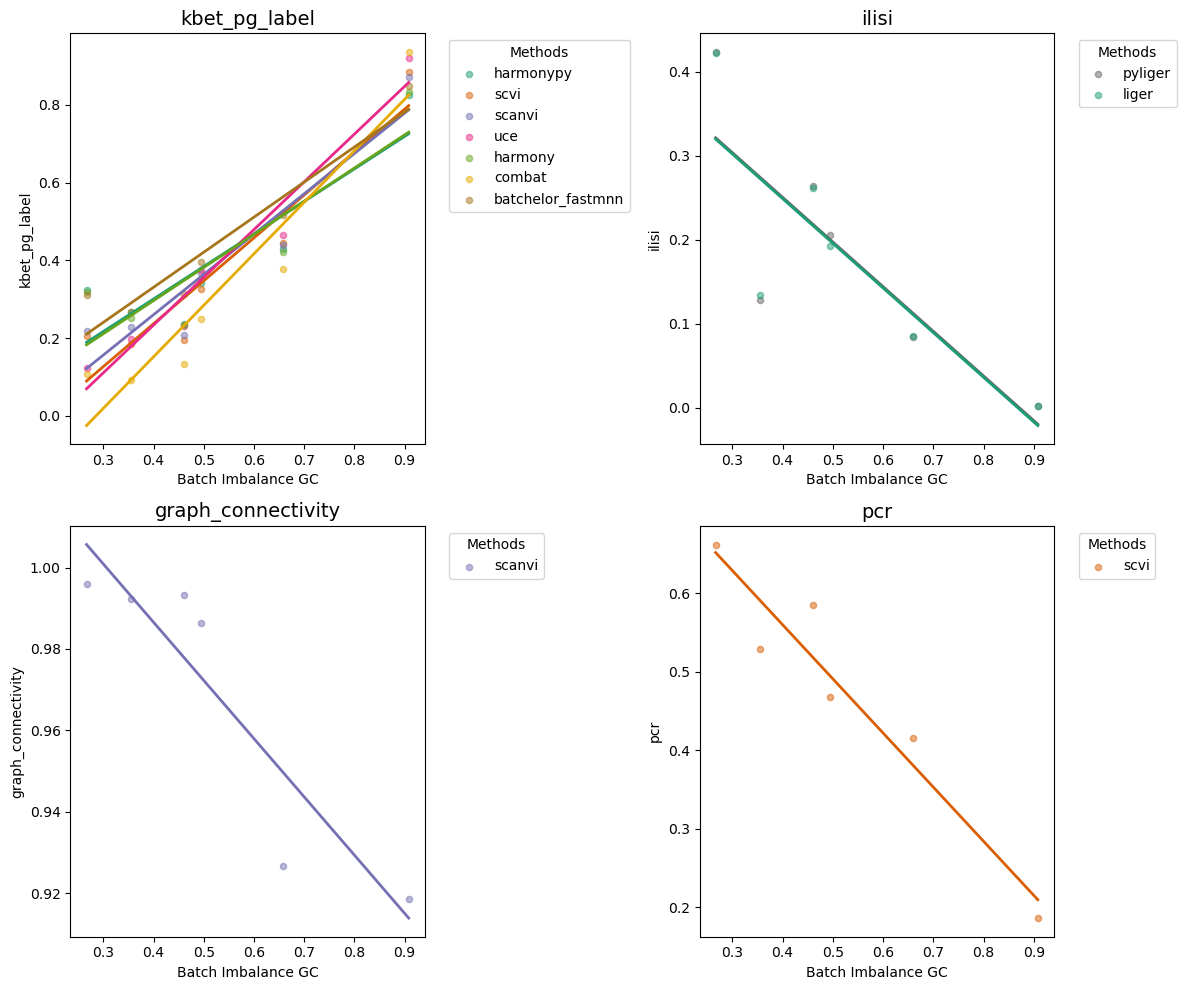

In [14]:
# 1. Define your mapping
metric_method_map = {
    "kbet_pg_label": ["batchelor_fastmnn", "combat", "harmony", "harmonypy", "scanvi", "scvi", "uce"],
    "ilisi": ["liger", "pyliger"],
    "graph_connectivity": ["scanvi"],
    "pcr": ["scvi"]
}

# 2. Filter the dataframe based on the mapping
frames = []
for metric, methods in metric_method_map.items():
    temp = df[(df['metric_id'] == metric) & (df['method_id'].isin(methods))]
    frames.append(temp)

df_summary = pd.concat(frames)

# 3. Setup Plotting Grid
metrics = list(metric_method_map.keys())
n_metrics = len(metrics)
ncols = 2 
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
axes = axes.ravel()

# 4. Iterate through metrics to build subplots
palette = sns.color_palette("Dark2", len(df_summary['method_id'].unique()))
method_colors = dict(zip(df_summary['method_id'].unique(), palette))

for i, metric in enumerate(metrics):
    ax = axes[i]
    df_plot = df_summary[df_summary['metric_id'] == metric]
    
    # Plot each method within this metric grid
    for method in df_plot['method_id'].unique():
        sub = df_plot[df_plot['method_id'] == method]
        color = method_colors[method]
        
        # Scatter
        ax.scatter(sub["batch_imbalance_gc"], sub["metric_value"], 
                   label=method, color=color, alpha=0.5, s=20)
        
        # Fit and Plot Regression
        if len(sub) > 1:
            res = smf.ols("metric_value ~ batch_imbalance_gc", data=sub).fit()
            x_range = np.linspace(sub["batch_imbalance_gc"].min(), sub["batch_imbalance_gc"].max(), 100)
            y_pred = res.predict(pd.DataFrame({"batch_imbalance_gc": x_range}))
            ax.plot(x_range, y_pred, color=color, linewidth=2)

    ax.set_title(f"{metric}", fontsize=14)
    ax.set_xlabel("Batch Imbalance GC")
    ax.set_ylabel(metric)
    ax.legend(title="Methods", bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Cleanup
for j in range(n_metrics, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("/Users/seohyon/Downloads/olc_summary_batch_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

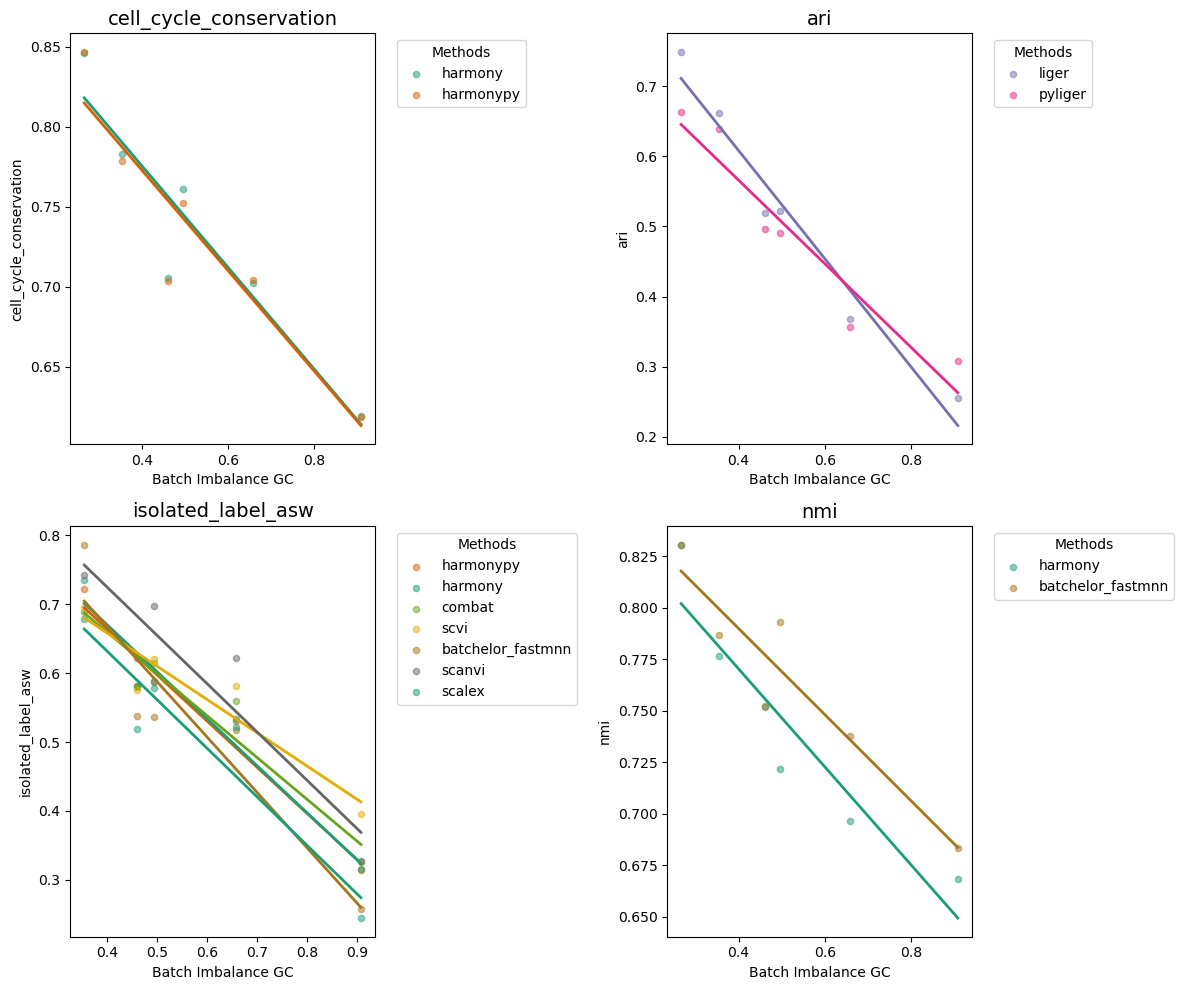

In [13]:
# 1. Define your mapping
metric_method_map = {
    "cell_cycle_conservation": ["harmony", "harmonypy"],
    "ari": ["liger", "pyliger"],
    "isolated_label_asw": ["batchelor_fastmnn", "combat", "harmony", "harmonypy", "scalex", "scanvi", "scvi"],
    "nmi": ["batchelor_fastmnn", "harmony"]
}

# 2. Filter the dataframe based on the mapping
frames = []
for metric, methods in metric_method_map.items():
    temp = df[(df['metric_id'] == metric) & (df['method_id'].isin(methods))]
    frames.append(temp)

df_summary = pd.concat(frames)

# 3. Setup Plotting Grid
metrics = list(metric_method_map.keys())
n_metrics = len(metrics)
ncols = 2 
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
axes = axes.ravel()

# 4. Iterate through metrics to build subplots
palette = sns.color_palette("Dark2", len(df_summary['method_id'].unique()))
method_colors = dict(zip(df_summary['method_id'].unique(), palette))

for i, metric in enumerate(metrics):
    ax = axes[i]
    df_plot = df_summary[df_summary['metric_id'] == metric]
    
    # Plot each method within this metric grid
    for method in df_plot['method_id'].unique():
        sub = df_plot[df_plot['method_id'] == method]
        color = method_colors[method]
        
        # Scatter
        ax.scatter(sub["batch_imbalance_gc"], sub["metric_value"], 
                   label=method, color=color, alpha=0.5, s=20)
        
        # Fit and Plot Regression
        if len(sub) > 1:
            res = smf.ols("metric_value ~ batch_imbalance_gc", data=sub).fit()
            x_range = np.linspace(sub["batch_imbalance_gc"].min(), sub["batch_imbalance_gc"].max(), 100)
            y_pred = res.predict(pd.DataFrame({"batch_imbalance_gc": x_range}))
            ax.plot(x_range, y_pred, color=color, linewidth=2)

    ax.set_title(f"{metric}", fontsize=14)
    ax.set_xlabel("Batch Imbalance GC")
    ax.set_ylabel(metric)
    ax.legend(title="Methods", bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Cleanup
for j in range(n_metrics, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("/Users/seohyon/Downloads/olc_summary_bio_metrics.png", dpi=300, bbox_inches="tight")
plt.show()